In [25]:
import numpy as np
from scipy import optimize
from tqdm import tqdm
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as cst

Consider a uniform 1D grid, dicretised in the domain $[x_L, x_R]$ and with physical size $\Delta x$. The position of each grid element is as follows: 

$$x_i = x_L+(i+1/2)\Delta x$$

We will also define the position of the boundary need the midpoint values:

$$x_{i-1/2} = x_i - \Delta x = x_L+i \Delta x$$

These values define computational cells or *control volumes*:
$$C_i = [x_{i-1/2},x_{i+1/2})$$

Any quantity $U$ of the cell at position $x_i$ and time $t_n$ are defined numerically as:

$$U(x_i, t_n) = \frac{1}{\Delta x}\int_{x_{i-1/2}}^{x_{i+1/2}}U(x,t_n)\, dx$$



In [26]:
import numpy as np

def hydroiso_cen(x, xi, rho, rhou, e, gamma, dt):
    nx = len(x)

    # velocity at cell interfaces
    ui = np.zeros(nx + 1)
    for ix in range(1, nx):
        ui[ix] = 0.5 * (rhou[ix] / rho[ix] + rhou[ix - 1] / rho[ix - 1])

    # flux for rho
    fluxrho = np.zeros(nx + 1)
    for ix in range(1, nx):
        if ui[ix] > 0.0:
            fluxrho[ix] = rho[ix - 1] * ui[ix]
        else:
            fluxrho[ix] = rho[ix] * ui[ix]

    # update density
    for ix in range(nx):
        rho[ix] = rho[ix] - (dt / (xi[ix + 1] - xi[ix])) * (fluxrho[ix + 1] - fluxrho[ix])

    # flux for rho * u
    fluxrhou = np.zeros(nx + 1)
    for ix in range(1, nx):
        if ui[ix] > 0.0:
            fluxrhou[ix] = rhou[ix - 1] ** 2 / rho[ix - 1]
        else:
            fluxrhou[ix] = rhou[ix] ** 2 / rho[ix]

    # update momentum
    for ix in range(nx):
        rhou[ix] = rhou[ix] - (dt / (xi[ix + 1] - xi[ix])) * (fluxrhou[ix + 1] - fluxrhou[ix])

    # pressure
    p = (gamma - 1.0) * rho * e

    # add pressure force (inner cells)
    for ix in range(1, nx - 1):
        rhou[ix] = rhou[ix] - dt * (p[ix + 1] - p[ix - 1]) / (x[ix + 1] - x[ix - 1])

    # boundary cells (mirror symmetry)
    rhou[0] -= 0.5 * dt * (p[1] - p[0]) / (x[1] - x[0])
    rhou[nx - 1] -= 0.5 * dt * (p[nx - 1] - p[nx - 2]) / (x[nx - 1] - x[nx - 2])


In [27]:
import numpy as np

nx = 100
nt = 1000
x0 = 0.0
x1 = 100.0
xmid = 0.5 * (x0 + x1)
dt = 0.25
cfl = 0.5

x = x0 + (x1 - x0) * (np.arange(nx) / (nx - 1.0))
gamma = 7.0 / 5.0

rho = np.zeros((nx, nt + 1))
rhou = np.zeros((nx, nt + 1))
e = np.ones(nx)
time = np.zeros(nt + 1)

dg = 0.1 * (x1 - x0)
rho[:, 0] = 1.0 + 0.3 * np.exp(-((x - xmid) ** 2) / (dg ** 2))

xi = np.zeros(nx + 1)
xi[1:nx] = 0.5 * (x[1:nx] + x[0:nx - 1])
xi[0] = 2 * xi[1] - xi[2]
xi[nx] = 2 * xi[nx - 1] - xi[nx - 2]

dx = xi[1:nx + 1] - xi[0:nx]

# time loop
for it in tqdm(range(1, nt + 1)):
    qrho = rho[:, it - 1].copy()
    qrhou = rhou[:, it - 1].copy()

    cs = np.sqrt(gamma * (gamma - 1) * e)
    dum = dx / (cs + np.abs(qrhou / qrho))
    dt = cfl * np.min(dum)

    time[it] = time[it - 1] + dt

    #print(f"Time step {it}, Time = {time[it]:.5f}, Dt = {dt:.5f}")

    hydroiso_cen(x, xi, qrho, qrhou, e, gamma, dt)

    rho[:, it] = qrho
    rhou[:, it] = qrhou

100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 4619.38it/s]


(Text(0.5, 0, 'x'), Text(0, 0.5, 't'))

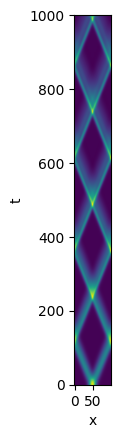

In [17]:
plt.imshow(rho.T, origin='lower')
plt.xlabel('x'), plt.ylabel('t')

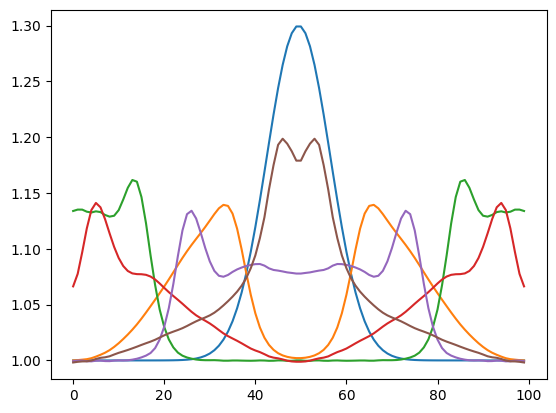

In [23]:
plt.plot(rho[:,slice(None, None, 200)])

In [29]:
import numpy as np


def advect(x, xi, q, ui, dt, fluxlim="donor-cell", nghost=2):
    nx = len(xi) - 1
    if len(x) != nx or len(q) != nx or len(ui) != nx + 1:
        raise ValueError("array size mismatch")
    if nghost < 1:
        raise ValueError("need at least one ghost cell")

    # compute r for flux limiter
    r = np.zeros(nx + 1)
    for i in range(2, nx - 2):
        dq = q[i] - q[i - 1]
        if abs(dq) > 0.0:
            if ui[i] >= 0.0:
                r[i] = (q[i - 1] - q[i - 2]) / dq
            else:
                r[i] = (q[i + 1] - q[i]) / dq

    # flux limiter
    phi = np.zeros(nx + 1)
    if fluxlim == "donor-cell":
        pass
    elif fluxlim == "superbee":
        for i in range(1, nx - 1):
            a = min(1.0, 2.0 * r[i])
            b = min(2.0, r[i])
            phi[i] = max(0.0, a, b)
    else:
        raise ValueError("unknown flux limiter")

    # flux
    flux = np.zeros(nx + 1)
    for i in range(1, nx):
        if ui[i] >= 0.0:
            flux[i] = ui[i] * q[i - 1]
        else:
            flux[i] = ui[i] * q[i]
        flux[i] += 0.5 * abs(ui[i]) * (1 - abs(ui[i] * dt / (x[i] - x[i - 1]))) * phi[i] * (q[i] - q[i - 1])

    # update q except ghost cells
    for i in range(nghost, nx - nghost):
        q[i] -= dt * (flux[i + 1] - flux[i]) / (xi[i + 1] - xi[i])


def boundary(rho, rhou, periodic=False, mirror=False):
    nx = len(rho)
    if periodic and mirror:
        raise ValueError("cannot have both periodic and mirror boundaries")

    if periodic:
        rho[0] = rho[nx - 4]
        rho[1] = rho[nx - 3]
        rho[nx - 2] = rho[2]
        rho[nx - 1] = rho[3]
        rhou[0] = rhou[nx - 4]
        rhou[1] = rhou[nx - 3]
        rhou[nx - 2] = rhou[2]
        rhou[nx - 1] = rhou[3]

    if mirror:
        rho[0] = rho[3]
        rho[1] = rho[2]
        rho[nx - 2] = rho[nx - 3]
        rho[nx - 1] = rho[nx - 4]
        rhou[0] = -rhou[3]
        rhou[1] = -rhou[2]
        rhou[nx - 2] = -rhou[nx - 3]
        rhou[nx - 1] = -rhou[nx - 4]


def hydrostep(x, xi, rho, rhou, e, gamma, dt, periodic=False, mirror=False,
              fluxlim="donor-cell", nrvisc=None):
    if periodic and mirror:
        raise ValueError("cannot set both periodic and mirror")

    nghost = 2
    if fluxlim is None:
        fluxlim = "donor-cell"

    nx = len(x)

    # impose boundary conditions
    boundary(rho, rhou, periodic=periodic, mirror=mirror)

    # velocity at cell interfaces
    ui = np.zeros(nx + 1)
    for ix in range(1, nx):
        ui[ix] = 0.5 * (rhou[ix] / rho[ix] + rhou[ix - 1] / rho[ix - 1])

    # advect rho and rho*u
    advect(x, xi, rho, ui, dt, fluxlim, nghost)
    advect(x, xi, rhou, ui, dt, fluxlim, nghost)

    # reapply boundaries
    boundary(rho, rhou, periodic=periodic, mirror=mirror)

    # pressure
    p = (gamma - 1.0) * rho * e

    # add pressure force (skip ghost cells)
    for ix in range(2, nx - 3):
        rhou[ix] -= dt * (p[ix + 1] - p[ix - 1]) / (x[ix + 1] - x[ix - 1])

    # final boundaries
    boundary(rho, rhou, periodic=periodic, mirror=mirror)


In [31]:
import numpy as np

nx = 100
nt = 1000
x0 = 0.0
x1 = 100.0
xmid = 0.5 * (x0 + x1)
dt = 0.25
cfl = 0.5

x = x0 + (x1 - x0) * (np.arange(nx) / (nx - 1.0))
gamma = 7.0 / 5.0

rho = np.zeros((nx, nt + 1))
rhou = np.zeros((nx, nt + 1))
e = np.ones(nx)
time = np.zeros(nt + 1)

dg = 0.1 * (x1 - x0)
rho[:, 0] = 1.0 + 0.3 * np.exp(-((x - xmid) ** 2) / (dg ** 2))

xi = np.zeros(nx + 1)
xi[1:nx] = 0.5 * (x[1:nx] + x[0:nx - 1])
xi[0] = 2 * xi[1] - xi[2]
xi[nx] = 2 * xi[nx - 1] - xi[nx - 2]

dx = xi[1:nx + 1] - xi[0:nx]

# time loop
for it in tqdm(range(1, nt + 1)):
    qrho = rho[:, it - 1].copy()
    qrhou = rhou[:, it - 1].copy()

    cs = np.sqrt(gamma * (gamma - 1) * e)
    dum = dx / (cs + np.abs(qrhou / qrho))
    dt = cfl * np.min(dum)

    time[it] = time[it - 1] + dt

    #print(f"Time step {it}, Time = {time[it]:.5f}, Dt = {dt:.5f}")

    #hydroiso_cen(x, xi, qrho, qrhou, e, gamma, dt)
    hydrostep(x, xi, qrho, qrhou, e, gamma, dt, mirror=True, fluxlim="superbee")
    
    rho[:, it] = qrho
    rhou[:, it] = qrhou

100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1928.89it/s]


(Text(0.5, 0, 'x'), Text(0, 0.5, 't'))

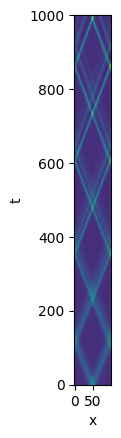

In [32]:
plt.imshow(rho.T, origin='lower')
plt.xlabel('x'), plt.ylabel('t')

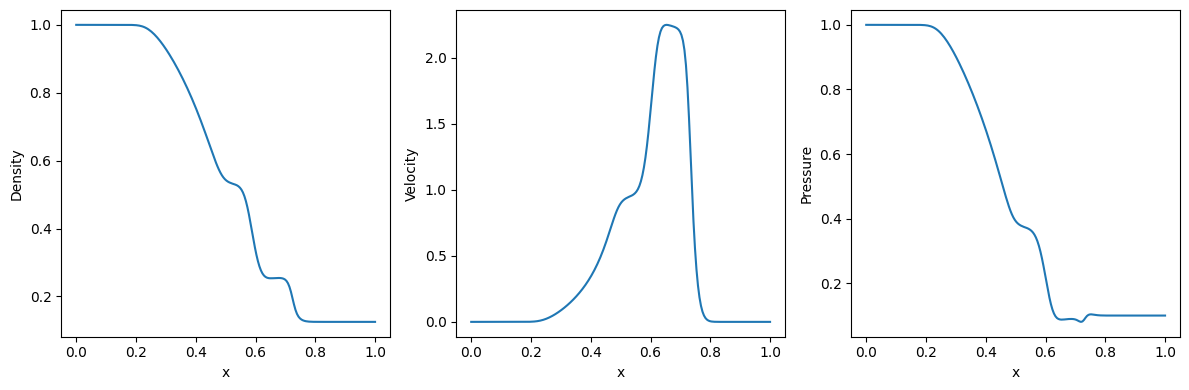

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Sod shock tube initial conditions
# -----------------------------
nx = 200          # number of cells
x0, x1 = 0.0, 1.0
x = np.linspace(x0, x1, nx)
dx = (x1 - x0)/nx
gamma = 1.4
t_end = 0.2

# conserved variables: [rho, rho*u, E]
U = np.zeros((nx, 3))

# left and right states
rhoL, uL, pL = 1.0, 0.0, 1.0
rhoR, uR, pR = 0.125, 0.0, 0.1

mid = nx // 2
U[:mid,0] = rhoL
U[:mid,1] = rhoL*uL
U[:mid,2] = pL/(gamma-1) + 0.5*rhoL*uL**2

U[mid:,0] = rhoR
U[mid:,1] = rhoR*uR
U[mid:,2] = pR/(gamma-1) + 0.5*rhoR*uR**2

# -----------------------------
# Helper functions
# -----------------------------
def compute_flux(U):
    rho = U[:,0]
    rhou = U[:,1]
    E = U[:,2]
    u = rhou/rho
    p = (gamma-1)*(E - 0.5*rho*u**2)
    F = np.zeros_like(U)
    F[:,0] = rhou
    F[:,1] = rhou*u + p
    F[:,2] = u*(E + p)
    return F

def hllc_flux(UL, UR):
    # Left and right states
    rhoL, uL, EL = UL
    rhoR, uR, ER = UR
    pL = (gamma-1)*(EL - 0.5*rhoL*uL**2)
    pR = (gamma-1)*(ER - 0.5*rhoR*uR**2)
    
    # sound speeds
    aL = np.sqrt(gamma*pL/rhoL)
    aR = np.sqrt(gamma*pR/rhoR)
    
    # estimate wave speeds (Davis 1988)
    SL = min(uL - aL, uR - aR)
    SR = max(uL + aL, uR + aR)
    
    # fluxes
    FL = np.array([rhoL*uL, rhoL*uL**2 + pL, uL*(EL+pL)])
    FR = np.array([rhoR*uR, rhoR*uR**2 + pR, uR*(ER+pR)])
    
    if SL >= 0:
        return FL
    elif SR <= 0:
        return FR
    else:
        S_star = (pR - pL + rhoL*uL*(SL - uL) - rhoR*uR*(SR - uR)) / \
                 (rhoL*(SL - uL) - rhoR*(SR - uR))
        U_starL = rhoL*(SL - uL)/(SL - S_star) * np.array([1, S_star, EL/rhoL + (S_star-uL)*(S_star + pL/(rhoL*(SL-uL)))])
        U_starR = rhoR*(SR - uR)/(SR - S_star) * np.array([1, S_star, ER/rhoR + (S_star-uR)*(S_star + pR/(rhoR*(SR-uR)))])
        if S_star >= 0:
            return FL + SL*(U_starL - UL)
        else:
            return FR + SR*(U_starR - UR)

# -----------------------------
# Time integration loop
# -----------------------------
CFL = 0.9
t = 0.0

while t < t_end:
    # compute primitive variables
    rho = U[:,0]
    u = U[:,1]/rho
    E = U[:,2]
    p = (gamma-1)*(E - 0.5*rho*u**2)
    a = np.sqrt(gamma*p/rho)
    
    dt = CFL*dx/np.max(np.abs(u)+a)
    if t + dt > t_end:
        dt = t_end - t
    
    # compute fluxes at interfaces
    F = np.zeros_like(U)
    for i in range(1, nx):
        F[i] = hllc_flux(U[i-1], U[i])
    
    # update conserved variables
    for i in range(1, nx-1):
        U[i] = U[i] - dt/dx*(F[i+1] - F[i])
    
    t += dt

# -----------------------------
# plot results
# -----------------------------
rho = U[:,0]
u = U[:,1]/rho
p = (gamma-1)*(U[:,2] - 0.5*rho*u**2)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(x, rho)
plt.xlabel("x"); plt.ylabel("Density")

plt.subplot(1,3,2)
plt.plot(x, u)
plt.xlabel("x"); plt.ylabel("Velocity")

plt.subplot(1,3,3)
plt.plot(x, p)
plt.xlabel("x"); plt.ylabel("Pressure")

plt.tight_layout()
plt.show()


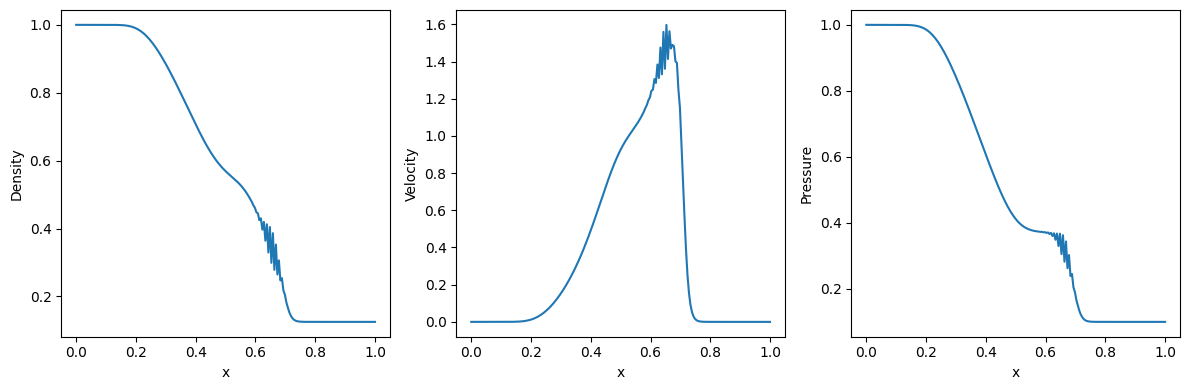

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Sod shock tube initial conditions
# -----------------------------
nx = 200
x0, x1 = 0.0, 1.0
x = np.linspace(x0, x1, nx)
dx = (x1 - x0)/nx
gamma = 1.4
t_end = 0.2

U = np.zeros((nx, 3))  # conserved variables [rho, rho*u, E]

# Left and right states
rhoL, uL, pL = 1.0, 0.0, 1.0
rhoR, uR, pR = 0.125, 0.0, 0.1

mid = nx // 2
U[:mid,0] = rhoL
U[:mid,1] = rhoL*uL
U[:mid,2] = pL/(gamma-1) + 0.5*rhoL*uL**2

U[mid:,0] = rhoR
U[mid:,1] = rhoR*uR
U[mid:,2] = pR/(gamma-1) + 0.5*rhoR*uR**2

# -----------------------------
# Roe flux function
# -----------------------------
def roe_flux(UL, UR):
    # primitive variables
    rhoL, uL, EL = UL
    rhoR, uR, ER = UR
    pL = (gamma-1)*(EL - 0.5*rhoL*uL**2)
    pR = (gamma-1)*(ER - 0.5*rhoR*uR**2)
    
    # fluxes
    FL = np.array([rhoL*uL, rhoL*uL**2 + pL, uL*(EL + pL)])
    FR = np.array([rhoR*uR, rhoR*uR**2 + pR, uR*(ER + pR)])
    
    # Roe averages
    sqrt_rhoL = np.sqrt(rhoL)
    sqrt_rhoR = np.sqrt(rhoR)
    uRoe = (sqrt_rhoL*uL + sqrt_rhoR*uR)/(sqrt_rhoL + sqrt_rhoR)
    H_L = (EL + pL)/rhoL
    H_R = (ER + pR)/rhoR
    H_Roe = (sqrt_rhoL*H_L + sqrt_rhoR*H_R)/(sqrt_rhoL + sqrt_rhoR)
    aRoe = np.sqrt((gamma-1)*(H_Roe - 0.5*uRoe**2))
    
    # eigenvalues
    lam = np.array([uRoe - aRoe, uRoe, uRoe + aRoe])
    
    # entropy fix
    delta = 0.1*aRoe
    lam = np.where(np.abs(lam) < delta, 0.5*(lam**2/delta + delta), lam)
    
    # differences
    dU = UR - UL
    
    # wave strengths (linearized)
    drho = dU[0]
    du = dU[1]/((rhoL+rhoR)/2)
    dP = (gamma-1)*(dU[2] - 0.5*(UL[1]**2/rhoL - UR[1]**2/rhoR))
    
    # Roe flux
    # Simple version: average flux - 0.5*|A|*dU
    # For simplicity, approximate |A|*dU as sum of |lambda|*alpha*r_i
    # Here we just use scalar dissipation
    alpha = np.abs(lam)
    flux = 0.5*(FL + FR) - 0.5*np.sum(alpha)*dU
    return flux

# -----------------------------
# Time integration
# -----------------------------
CFL = 0.9
t = 0.0

while t < t_end:
    rho = U[:,0]
    u = U[:,1]/rho
    E = U[:,2]
    p = (gamma-1)*(E - 0.5*rho*u**2)
    a = np.sqrt(gamma*p/rho)
    
    dt = CFL*dx/np.max(np.abs(u)+a)
    if t + dt > t_end:
        dt = t_end - t
    
    F = np.zeros_like(U)
    for i in range(1, nx):
        F[i] = roe_flux(U[i-1], U[i])
    
    for i in range(1, nx-1):
        U[i] -= dt/dx*(F[i+1] - F[i])
    
    t += dt

# -----------------------------
# plot results
# -----------------------------
rho = U[:,0]
u = U[:,1]/rho
p = (gamma-1)*(U[:,2] - 0.5*rho*u**2)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(x, rho)
plt.xlabel("x"); plt.ylabel("Density")

plt.subplot(1,3,2)
plt.plot(x, u)
plt.xlabel("x"); plt.ylabel("Velocity")

plt.subplot(1,3,3)
plt.plot(x, p)
plt.xlabel("x"); plt.ylabel("Pressure")

plt.tight_layout()
plt.show()


In [4]:
# Grid parameters
Nx = 100
Nt = 1000
x_left, x_right = 0, Nx

dt = 0.25

x_grid = x_left + (x_right-x_left)*np.arange(Nx)/(Nx - 1.)

boxsize = 1. #* u.cm
dx = boxsize/Nx

grid = x_left + (np.arange(Nx)+1/2)*dx
grid_mid = x_left + np.arange(Nx)*dx

In [5]:
grid_mid

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])

In [6]:
# Simulation parameters
N = 128 # resolution
boxsize = 1. * u.cm
dx = boxsize/N
vol = dx**3
area = dx**2
gamma = 5./3     # adiabatic index for ideal gas

# mesh grid
x_mid = np.linspace(0.5*dx, boxsize-0.5*dx, N)
X = x_mid

# Time
t_start = 0 * u.s
t_end = 60 * u.s
Nt = 1000
time = np.linspace(t_start, t_end, Nt+1)

# Initial Conditions
mean_weight = 1.67e-24 * u.g
rho0 = np.ones(N) * mean_weight /u.cm**3
ndens0 = rho0/mean_weight
T0 = np.ones(N) * u.K
T0[N//2] = 1e2 * u.K
#T0[1] = 1e2 * u.K

np.random.seed(2025)
v0 = np.random.normal(loc=0, scale=0.1, size=N) * u.cm/u.s
#rho0 = np.ones(N) * cosmo.critical_density0
#ndens0 = rho0/cst.m_p/molecular_weight

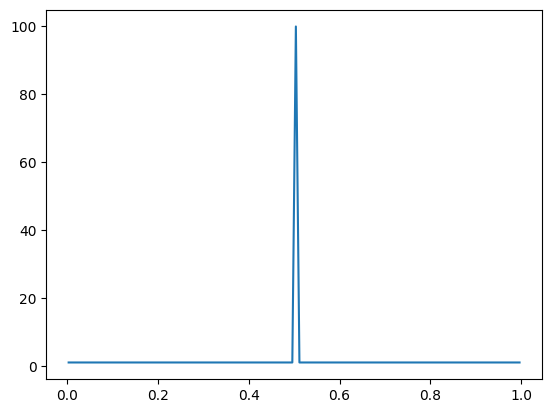

In [7]:
plt.plot(x_mid, T0)

In [8]:
def pressure(ndens, T):
    P = ndens*cst.k_B*T
    return P.to('g/(cm*s^2)')#.to('Pa')

def energy_density(rho, v, P, gamma):
    energy = P/(gamma-1)  + 0.5*rho*np.linalg.norm(v)**2
    return energy.to('erg/cm^3')

def temperature(ndens, E, gamma):
    temp = (gamma-1)*E/(cst.k_B*ndens)
    return temp.to('K')


# Convert to primitive variables
def primitive(W):
    rho = W[0]
    v = W[1] / rho
    E = W[2]
    P = (gamma - 1)*(E - 0.5*rho*np.linalg.norm(v)**2)
    return rho, v, P

# flux vector
def flux(W):
    rho, v, P = primitive(W)
    F = np.zeros_like(W)
    F[0] = W[1]
    F[1] = W[0] * np.linalg.norm(v)**2 + P
    F[2] = (W[2] + P) * v
    return F

#P0 = pressure(ndens=ndens0, T=T0)
#E0 = energy_density(rho=rho0, v=v0, P=P0, gamma=5./3)
#T0_f = temperature(ndens=ndens0, E=E0, gamma=5./3)
#print(T0_f)

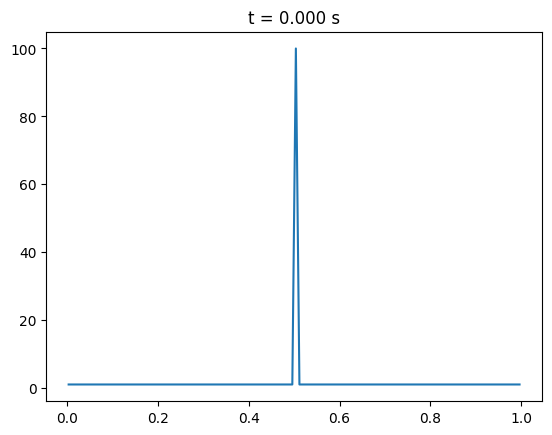

1.1638172502541695e-69 s
1.1638172502541695e-69 s


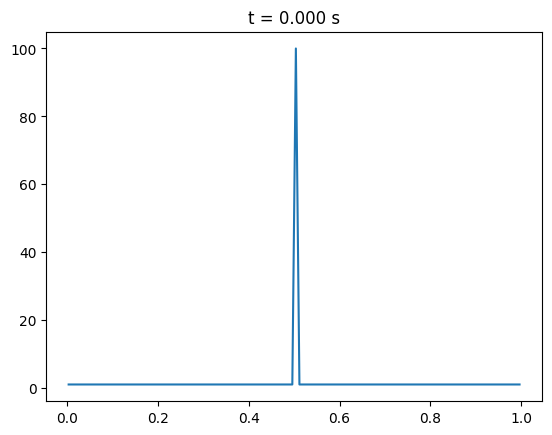

1.0286788371457556e-70 s
1.0286788371457556e-70 s


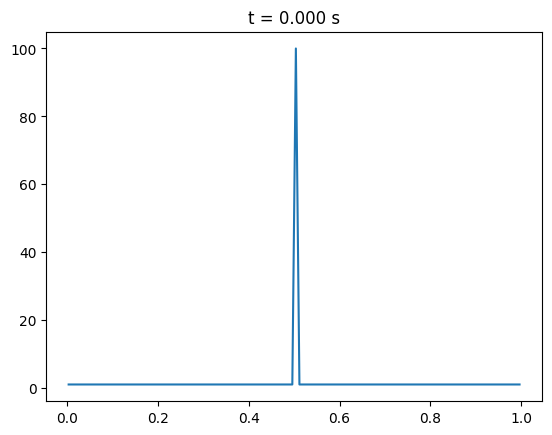

9.092322267610699e-72 s
9.092322267610699e-72 s


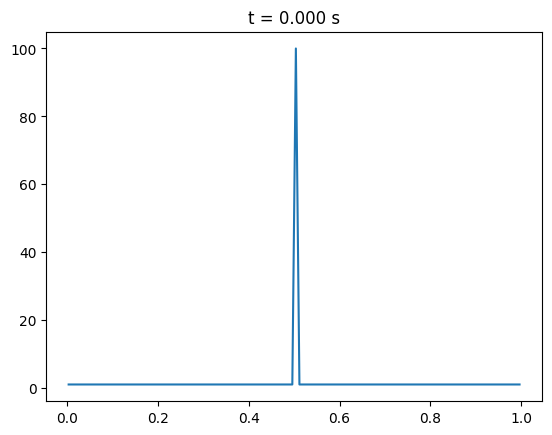

8.036553415201216e-73 s
8.036553415201216e-73 s


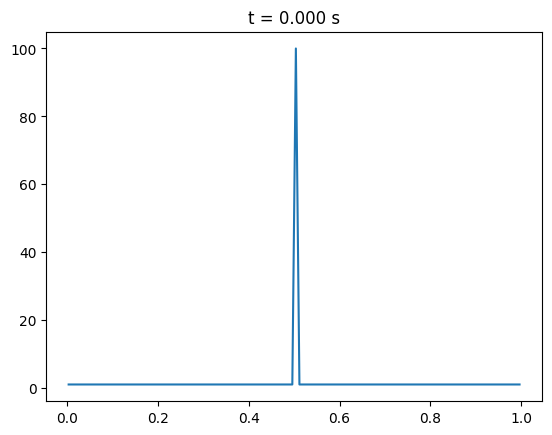

7.103376771570859e-74 s
7.103376771570859e-74 s


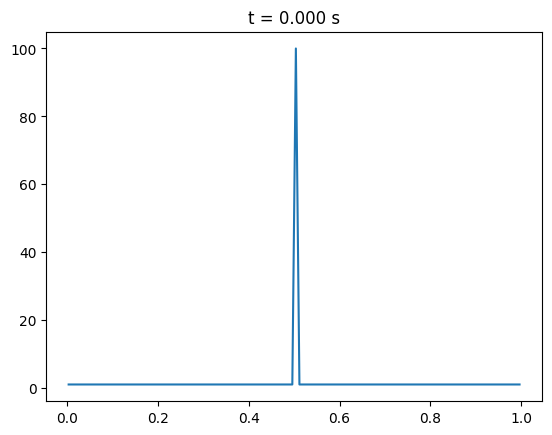

6.27855735562595e-75 s
6.27855735562595e-75 s


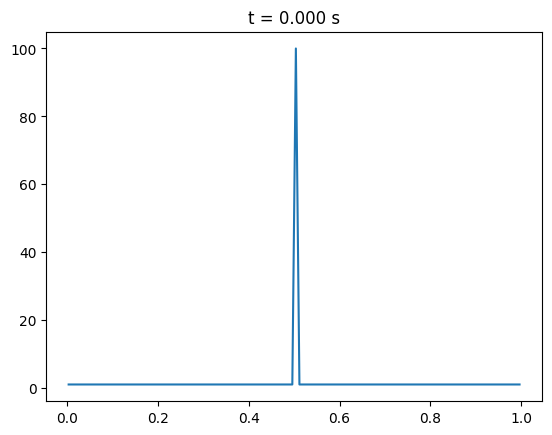

5.549513102789733e-76 s
5.549513102789733e-76 s


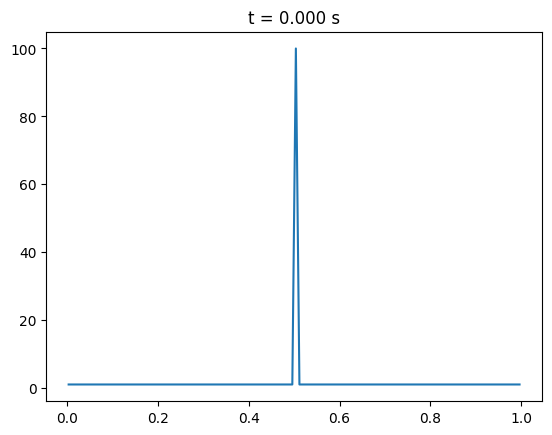

4.905122934082773e-77 s
4.905122934082773e-77 s


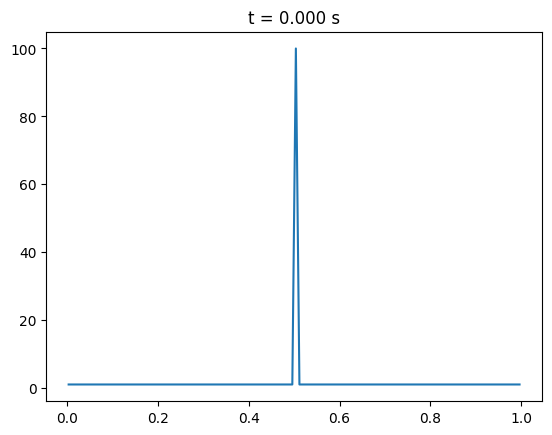

4.335557111554479e-78 s
4.335557111554479e-78 s


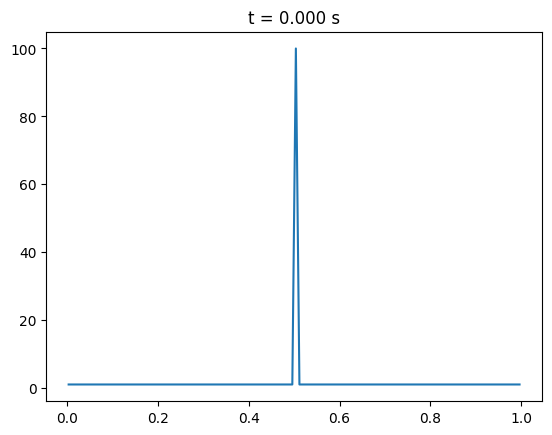

3.8321272922521667e-79 s
3.8321272922521667e-79 s


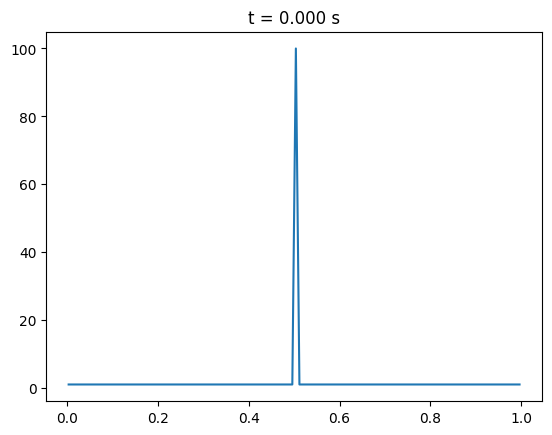

3.387153993401937e-80 s
3.387153993401937e-80 s


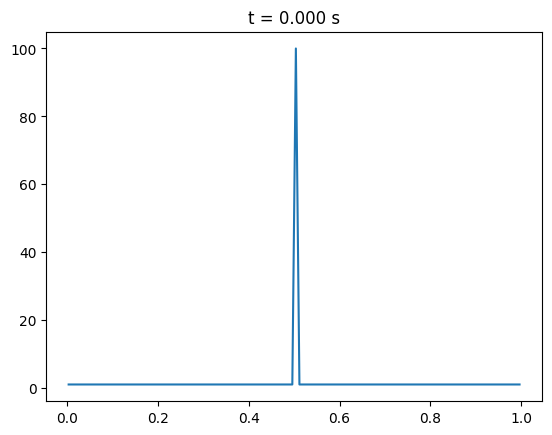

2.993849447072005e-81 s
2.993849447072005e-81 s


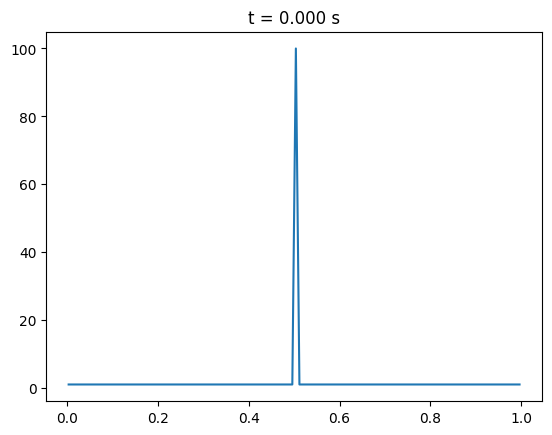

2.646214057345263e-82 s
2.646214057345263e-82 s


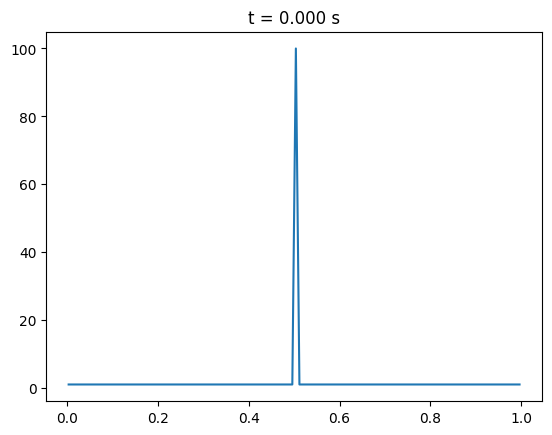

2.338944880525004e-83 s
2.338944880525004e-83 s


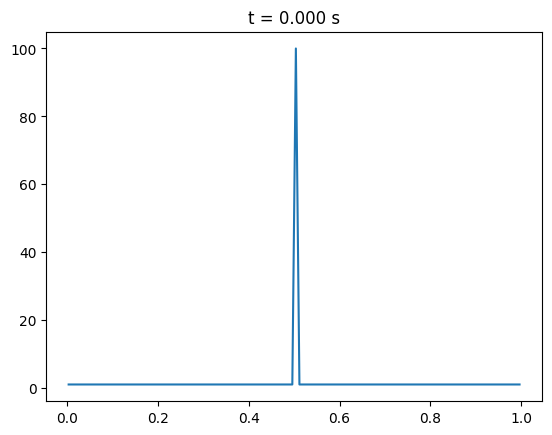

2.067354732300987e-84 s
2.067354732300987e-84 s


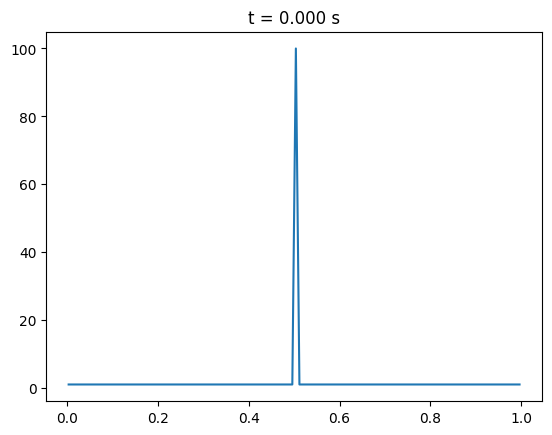

1.8273006879101594e-85 s
1.8273006879101594e-85 s


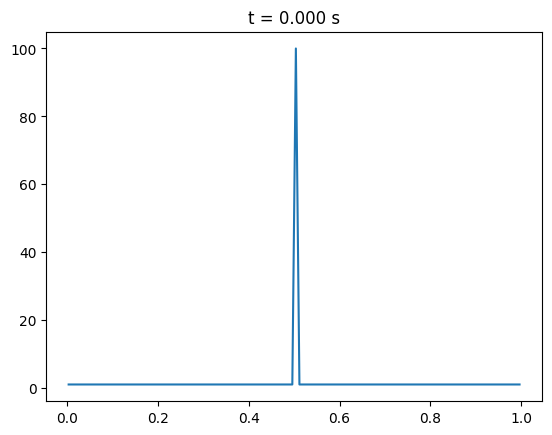

1.615120884610146e-86 s
1.615120884610146e-86 s


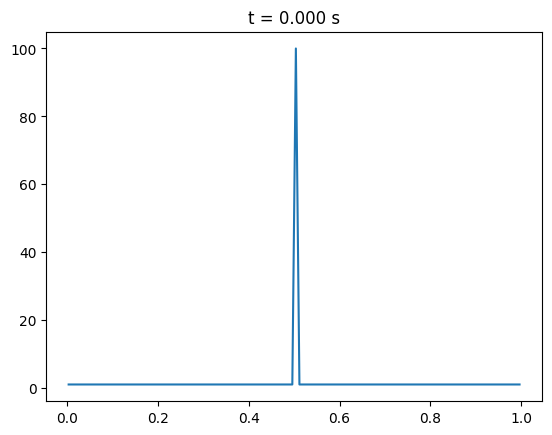

1.427578662429812e-87 s
1.427578662429812e-87 s


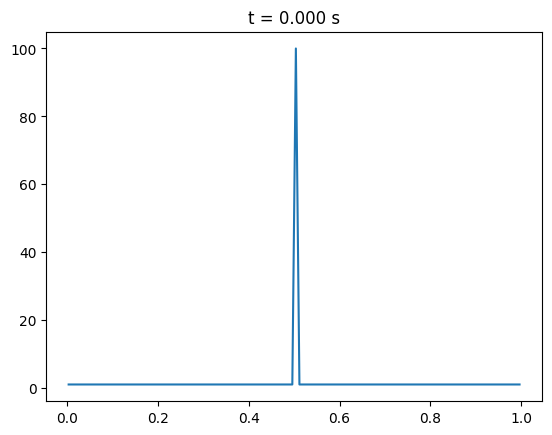

1.2618131911016765e-88 s
1.2618131911016765e-88 s


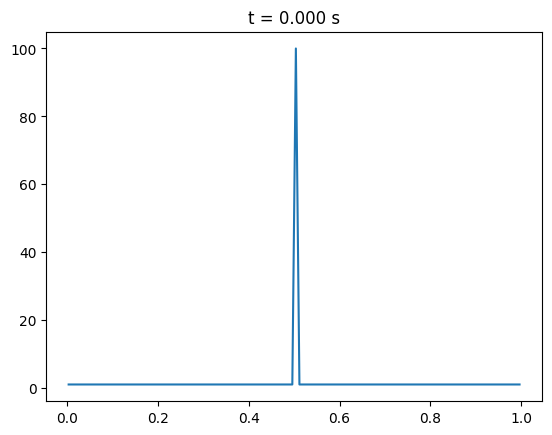

1.1152958300232907e-89 s
1.1152958300232907e-89 s


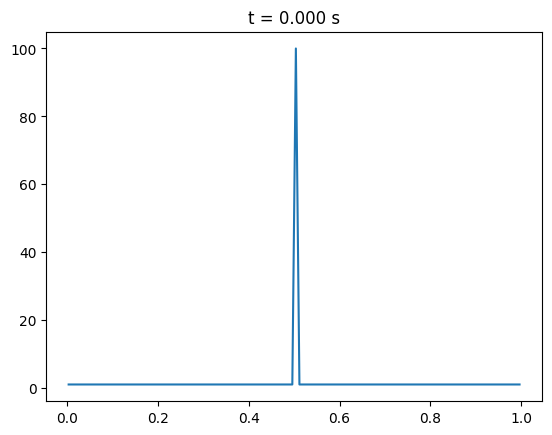

9.857915555481848e-91 s
9.857915555481848e-91 s


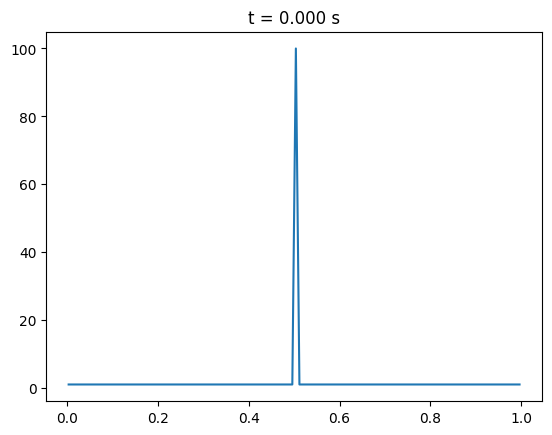

8.713248672056958e-92 s
8.713248672056958e-92 s


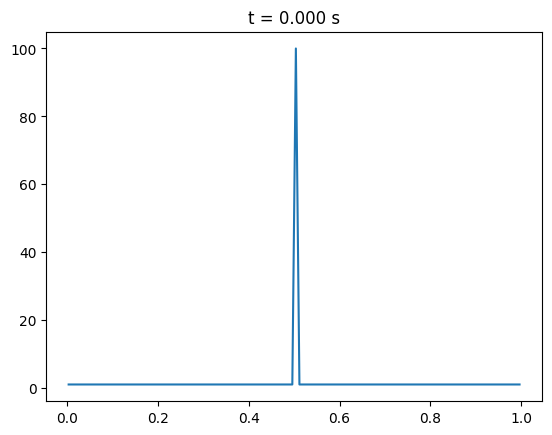

7.701496527720194e-93 s
7.701496527720194e-93 s


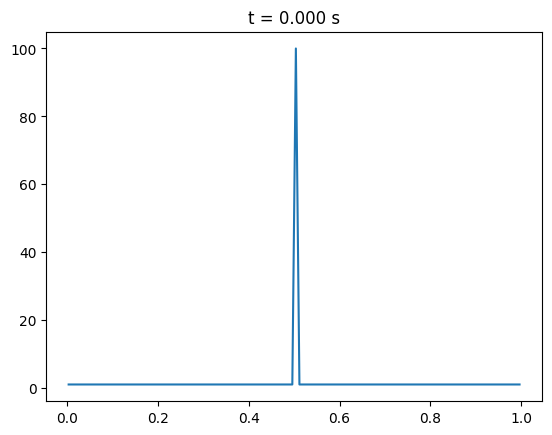

6.807225525044499e-94 s
6.807225525044499e-94 s


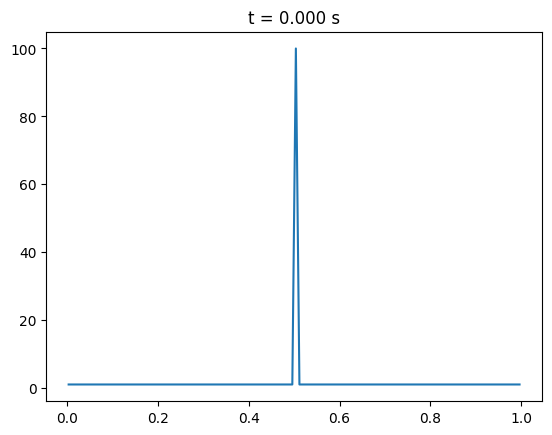

6.016794162281401e-95 s
6.016794162281401e-95 s


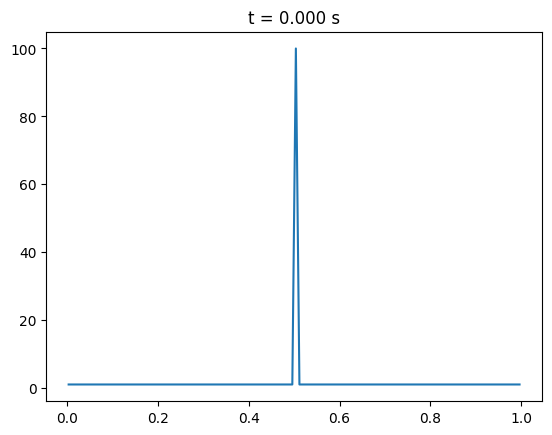

5.318144941441015e-96 s
5.318144941441015e-96 s


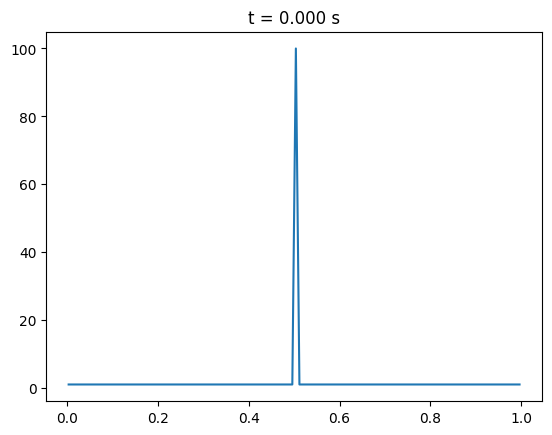

4.700620439282345e-97 s
4.700620439282345e-97 s


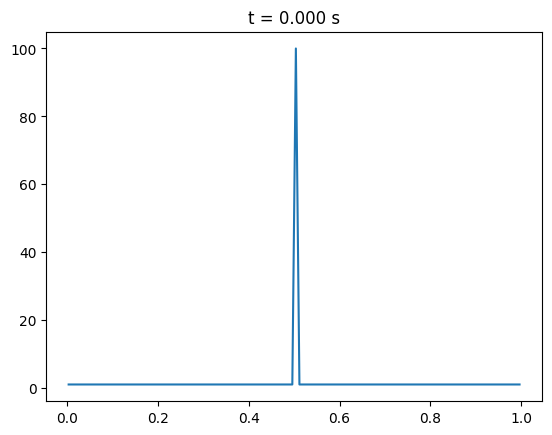

4.154800735500793e-98 s
4.154800735500793e-98 s


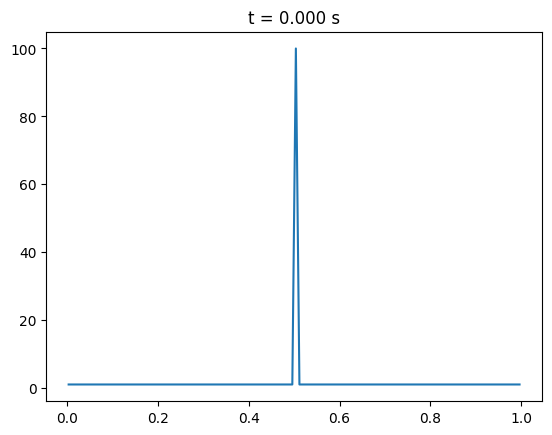

3.672359718189332e-99 s
3.672359718189332e-99 s


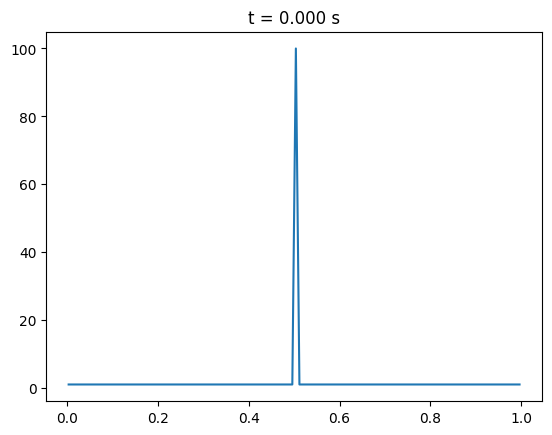

3.2459380746099943e-100 s
3.2459380746099943e-100 s


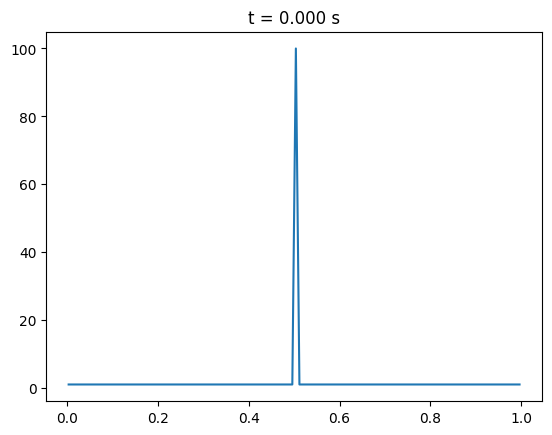

2.8690310298354155e-101 s
2.8690310298354155e-101 s


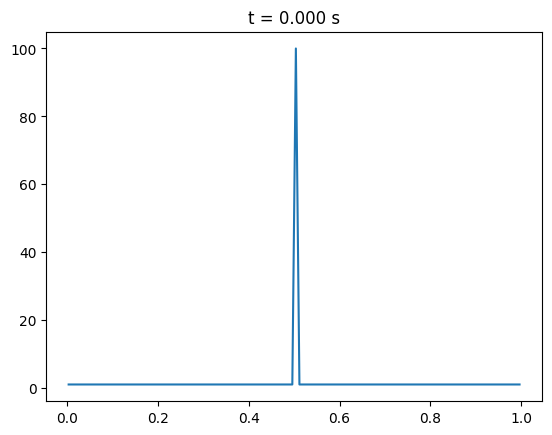

2.535889120789058e-102 s
2.535889120789058e-102 s


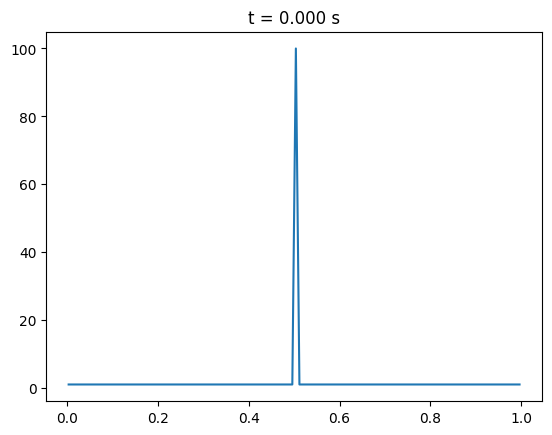

2.2414304920589183e-103 s
2.2414304920589183e-103 s


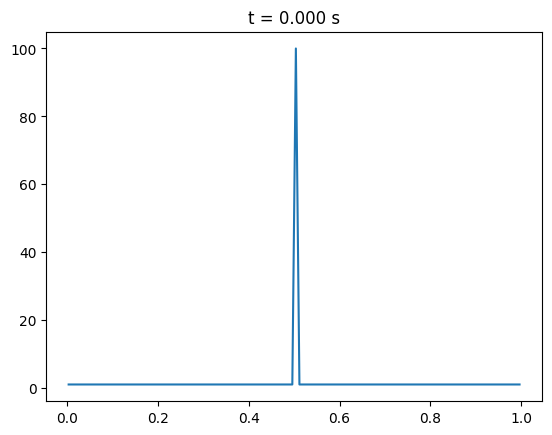

1.9811633756164516e-104 s
1.9811633756164516e-104 s


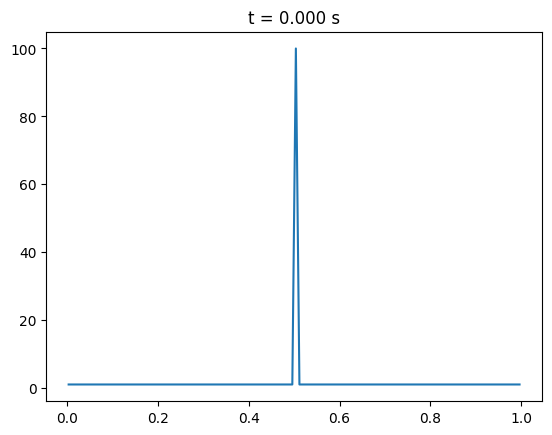

1.75111757192103e-105 s
1.75111757192103e-105 s


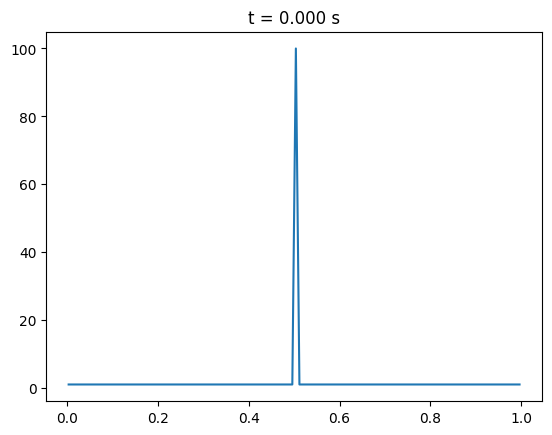

1.5477838872003528e-106 s
1.5477838872003528e-106 s


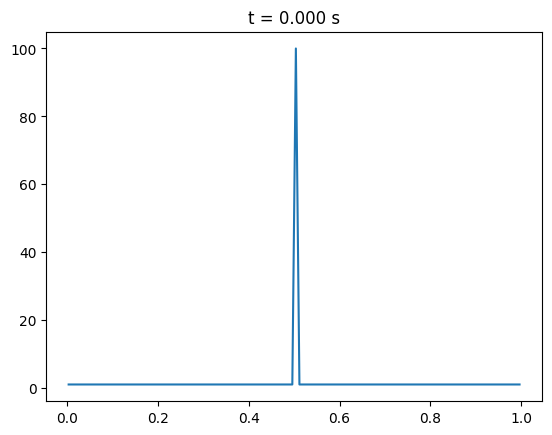

1.3680606030633047e-107 s
1.3680606030633047e-107 s


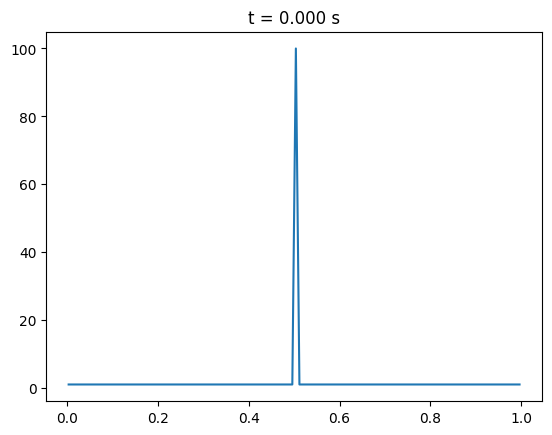

1.2092061618752756e-108 s
1.2092061618752756e-108 s


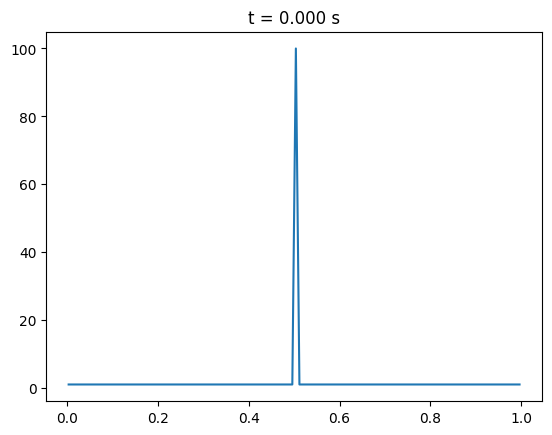

1.0687973461432068e-109 s
1.0687973461432068e-109 s


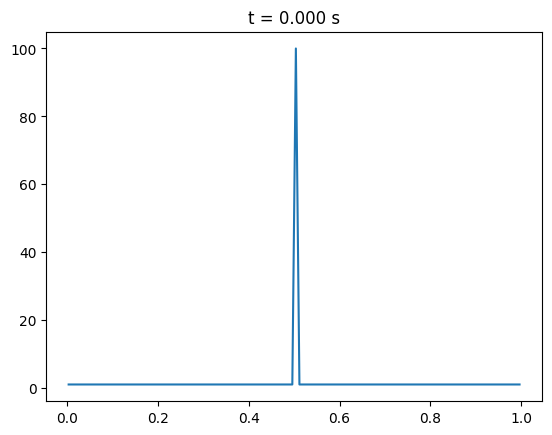

9.446923139650591e-111 s
9.446923139650591e-111 s


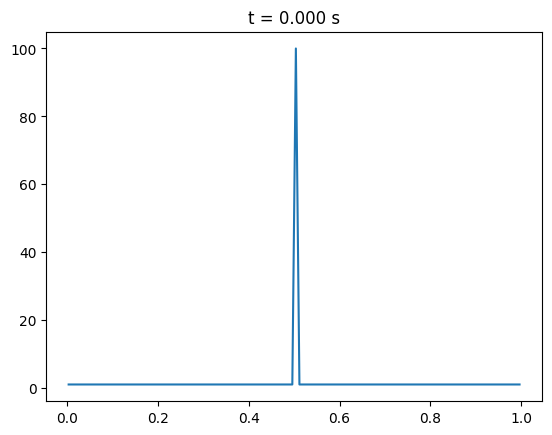

8.349979266743803e-112 s
8.349979266743803e-112 s


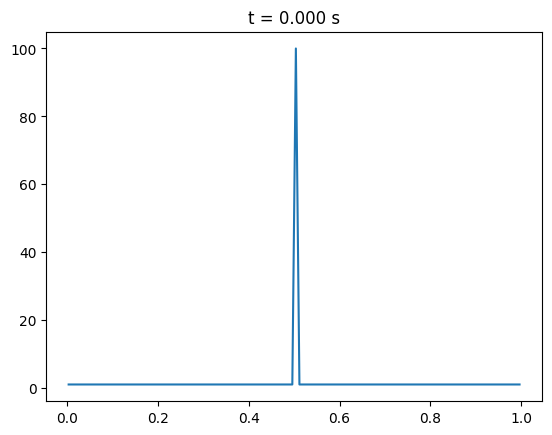

7.380408702852024e-113 s
7.380408702852024e-113 s


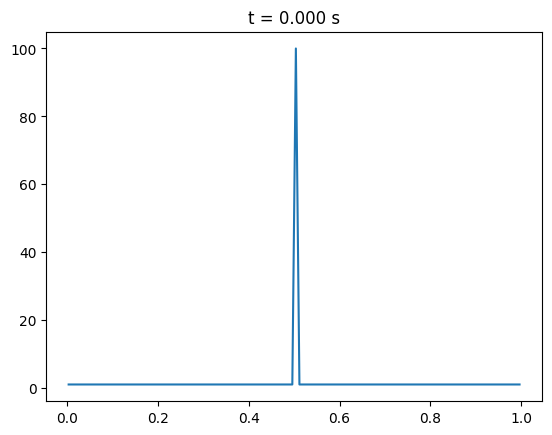

6.523421302143596e-114 s
6.523421302143596e-114 s


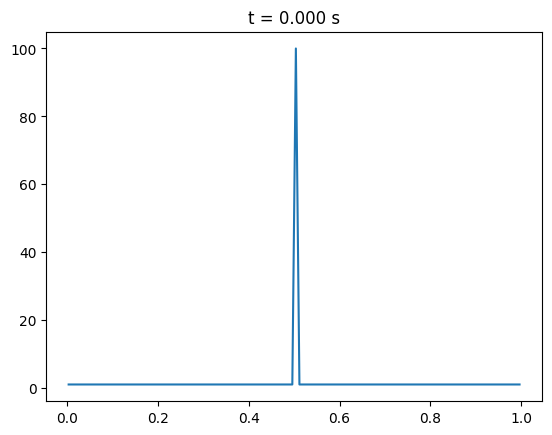

5.765944299103144e-115 s
5.765944299103144e-115 s


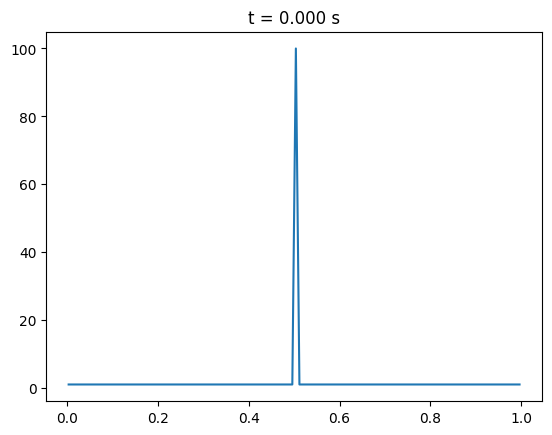

5.096422892299684e-116 s
5.096422892299684e-116 s


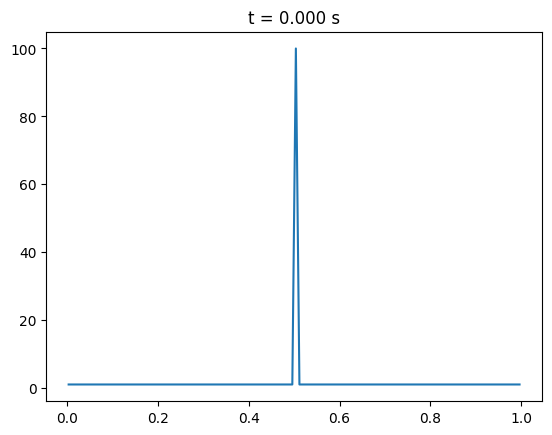

4.504643983674331e-117 s
4.504643983674331e-117 s


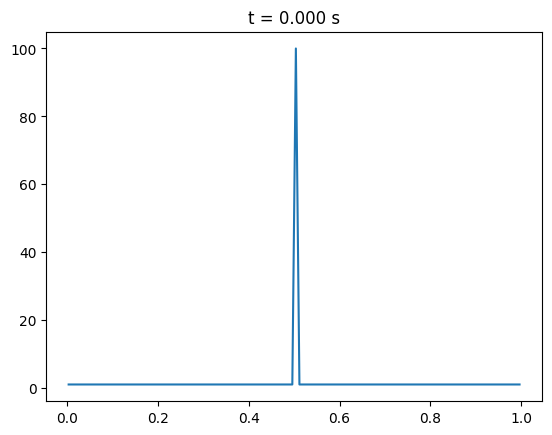

3.981580384609128e-118 s
3.981580384609128e-118 s


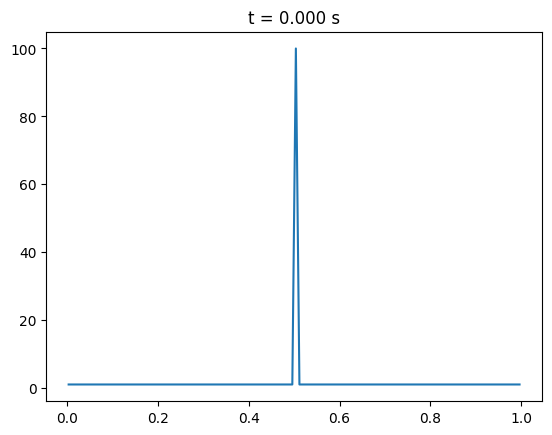

3.519253112245571e-119 s
3.519253112245571e-119 s


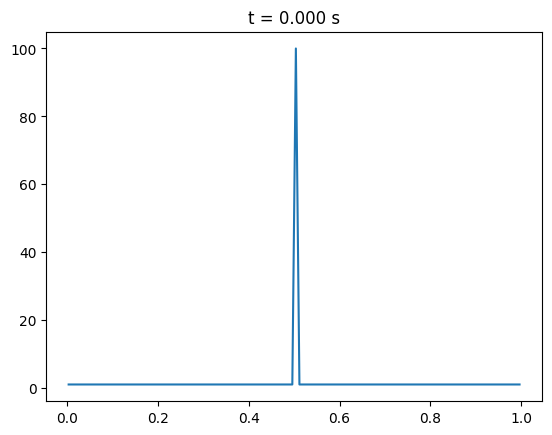

3.1106096754758816e-120 s
3.1106096754758816e-120 s


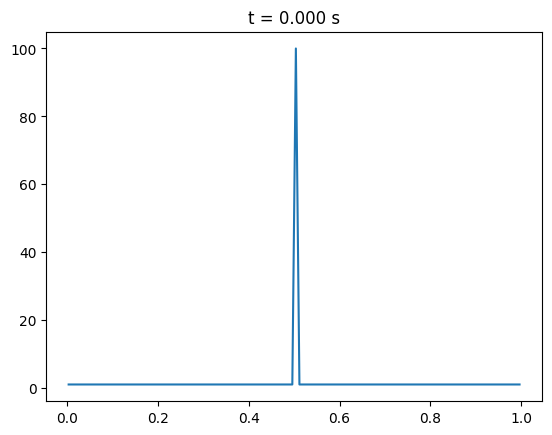

2.7494164939418525e-121 s
2.7494164939418525e-121 s


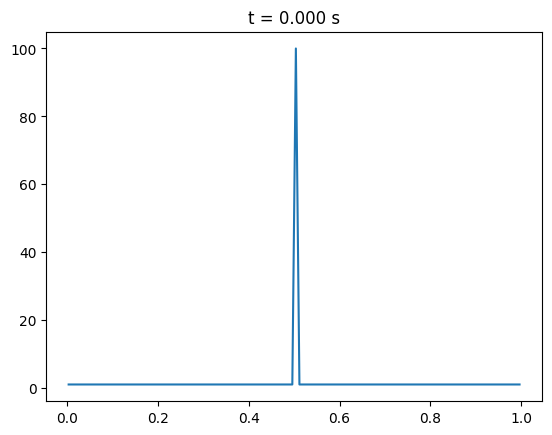

2.4301638089655325e-122 s
2.4301638089655325e-122 s


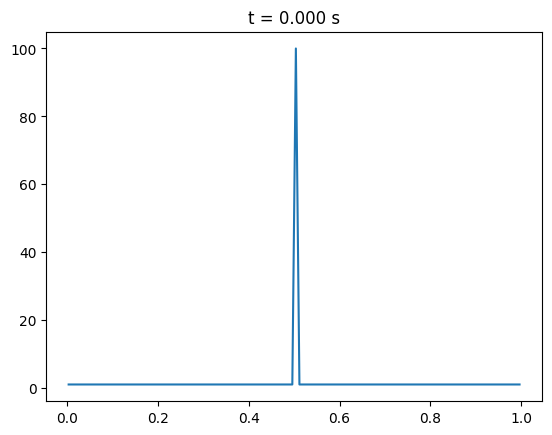

2.1479816358920723e-123 s
2.1479816358920723e-123 s


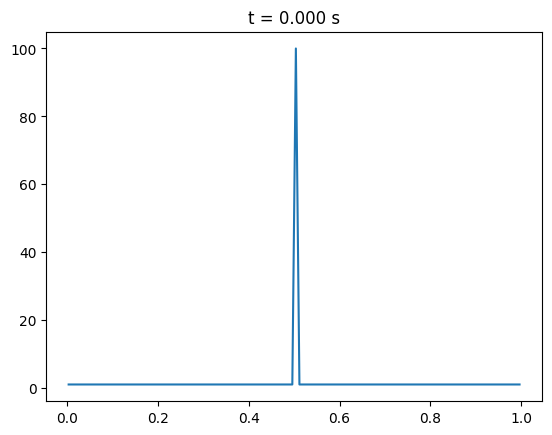

1.8985654757543222e-124 s
1.8985654757543222e-124 s


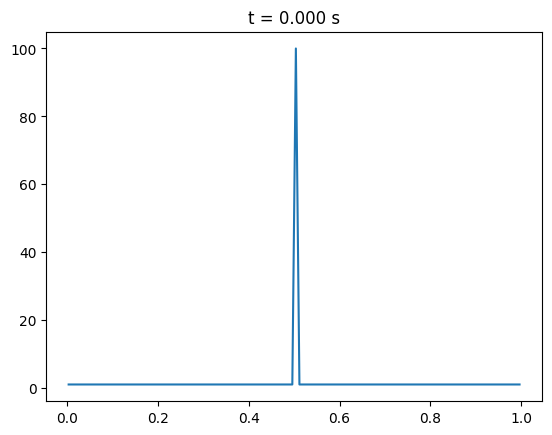

1.6781106530406814e-125 s
1.6781106530406814e-125 s


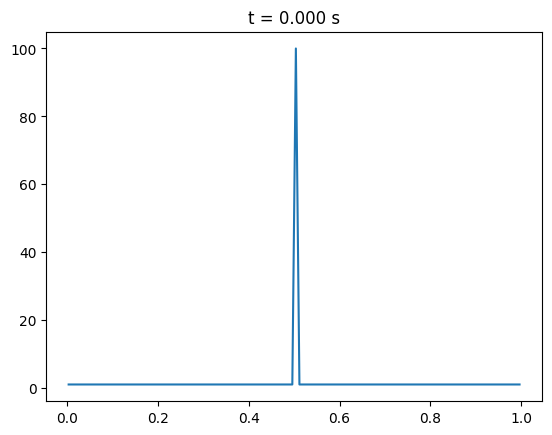

1.4832542779330643e-126 s
1.4832542779330643e-126 s


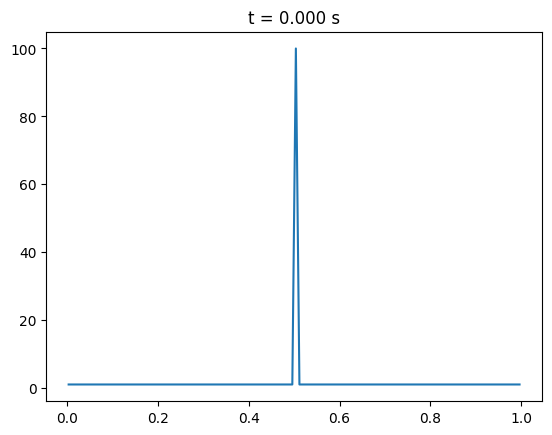

1.3110239476880324e-127 s
1.3110239476880324e-127 s


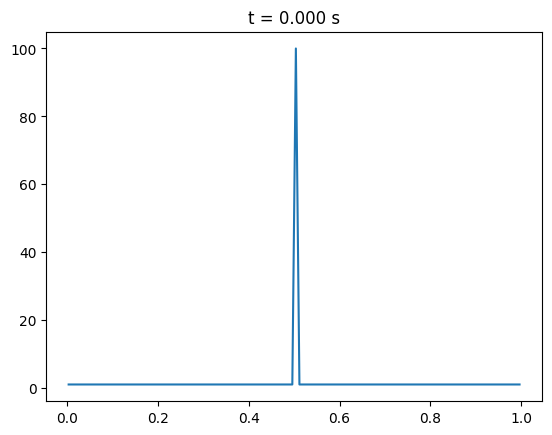

1.1587924046352064e-128 s
1.1587924046352064e-128 s


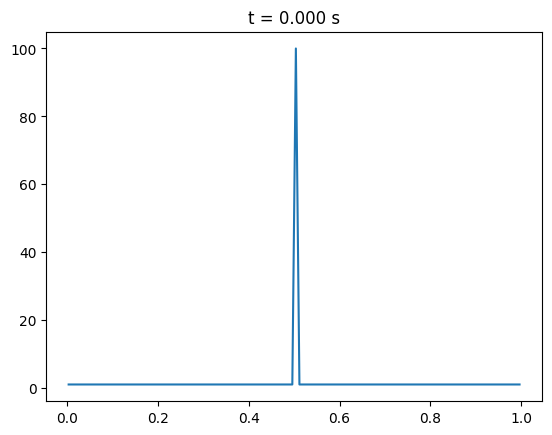

1.0242374591312753e-129 s
1.0242374591312753e-129 s


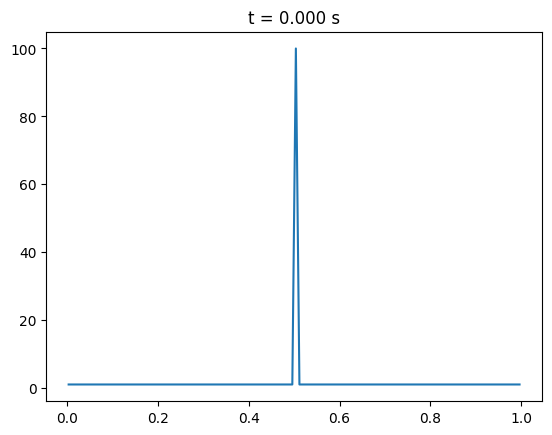

9.05306566121255e-131 s
9.05306566121255e-131 s


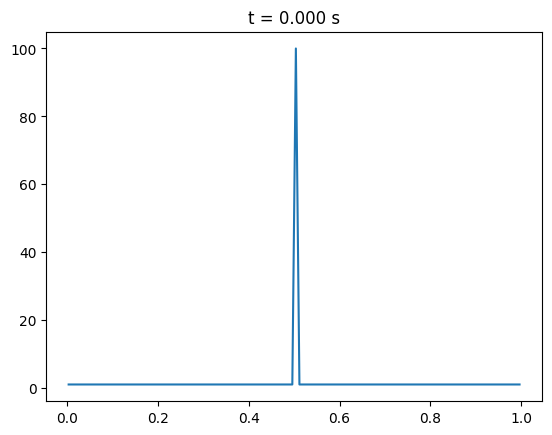

8.001855149463088e-132 s
8.001855149463088e-132 s


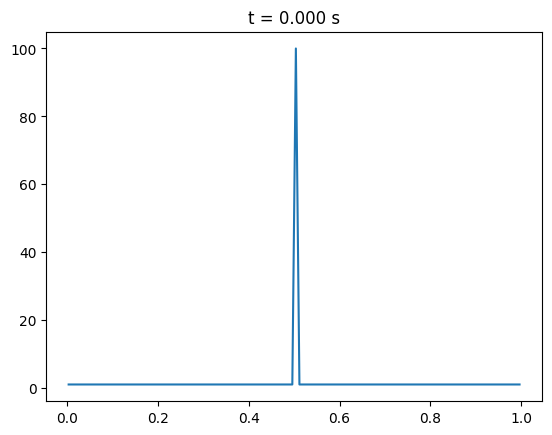

7.072707547822305e-133 s
7.072707547822305e-133 s


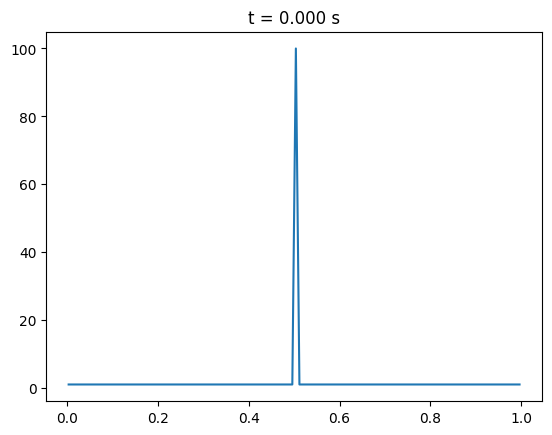

6.251449335518038e-134 s
6.251449335518038e-134 s


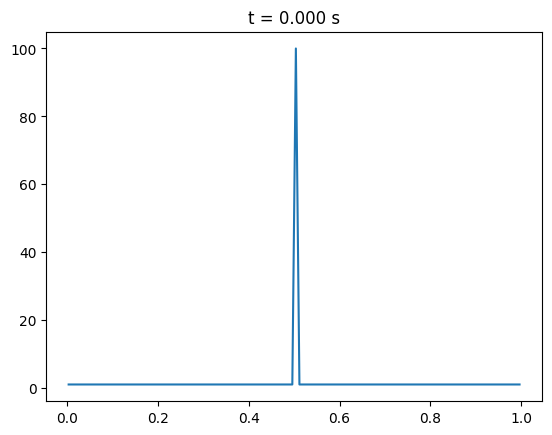

5.525552771736176e-135 s
5.525552771736176e-135 s


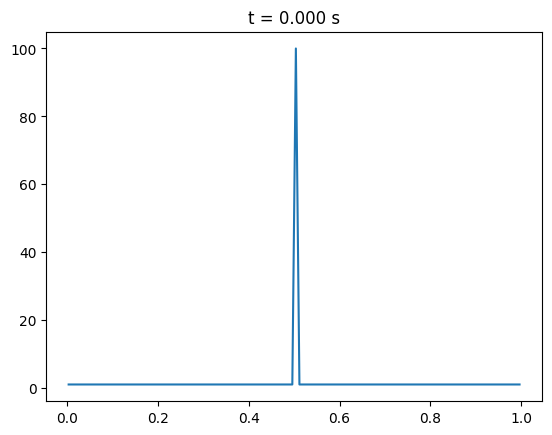

4.883944793373467e-136 s
4.883944793373467e-136 s


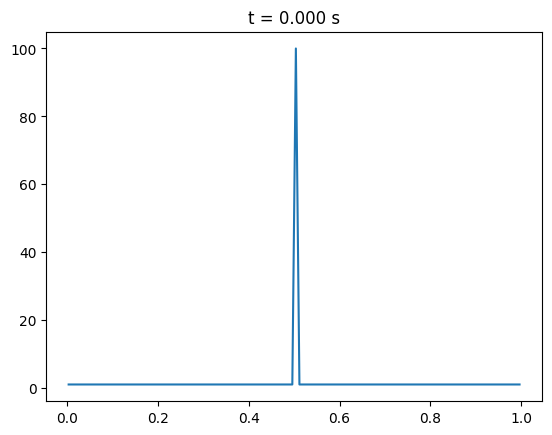

4.316838102918887e-137 s
4.316838102918887e-137 s


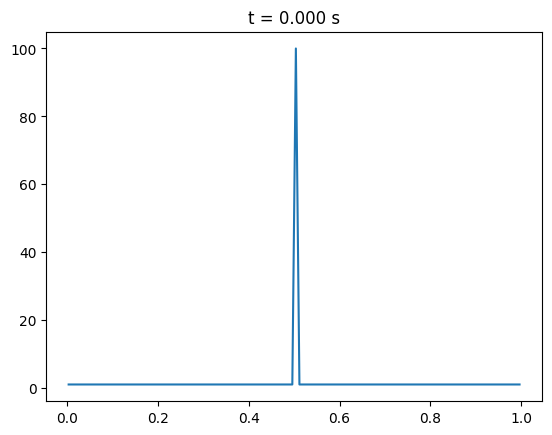

3.815581869823021e-138 s
3.815581869823021e-138 s


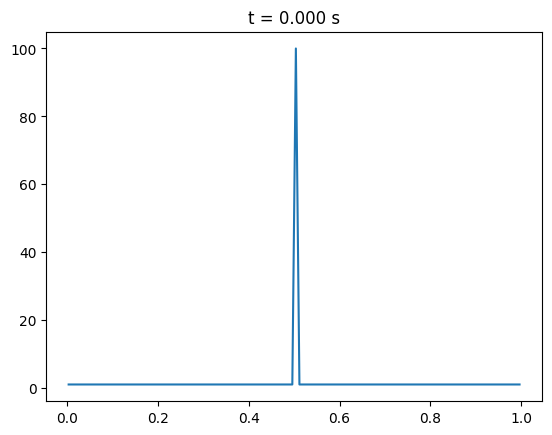

3.372529767905381e-139 s
3.372529767905381e-139 s


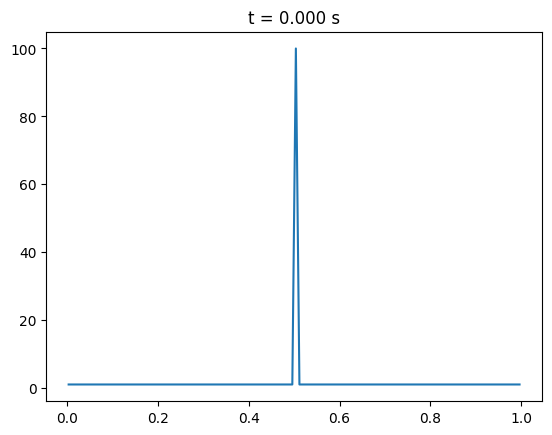

2.980923335799235e-140 s
2.980923335799235e-140 s


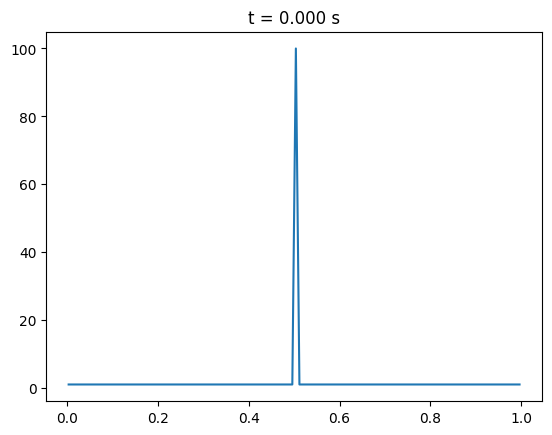

2.6347888811760787e-141 s
2.6347888811760787e-141 s


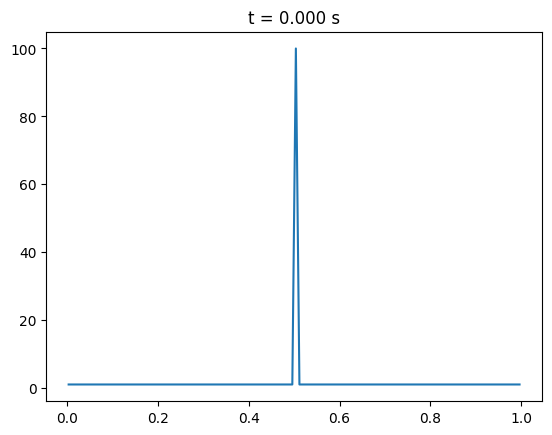

2.3288463560931525e-142 s
2.3288463560931525e-142 s


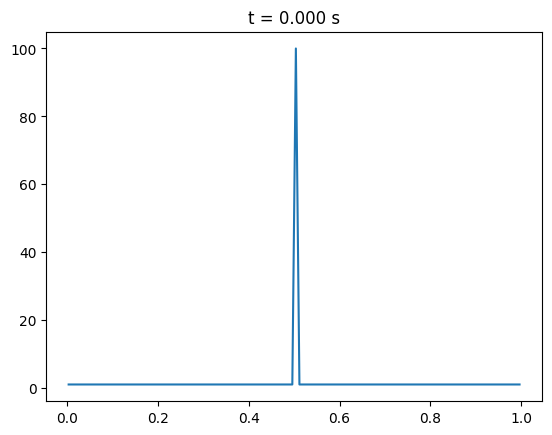

2.0584288134188115e-143 s
2.0584288134188115e-143 s


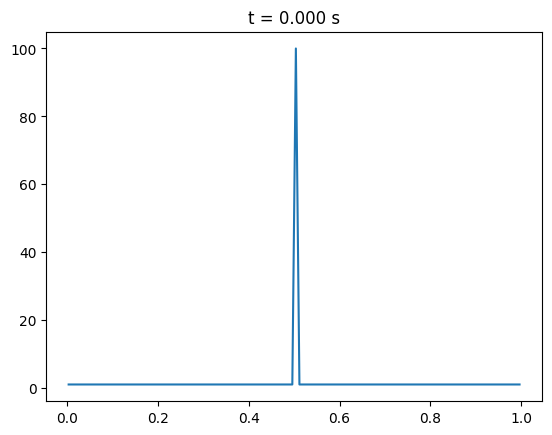

1.8194112156977754e-144 s
1.8194112156977754e-144 s


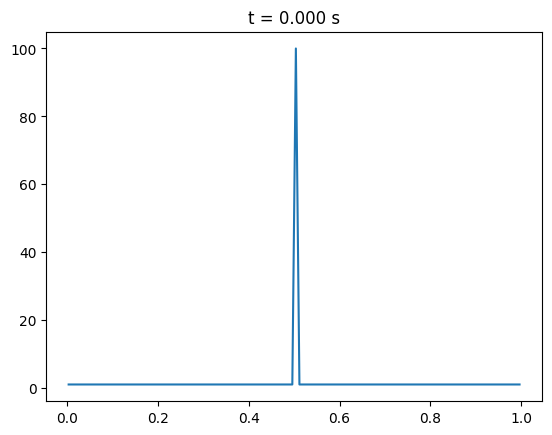

1.6081475104834465e-145 s
1.6081475104834465e-145 s


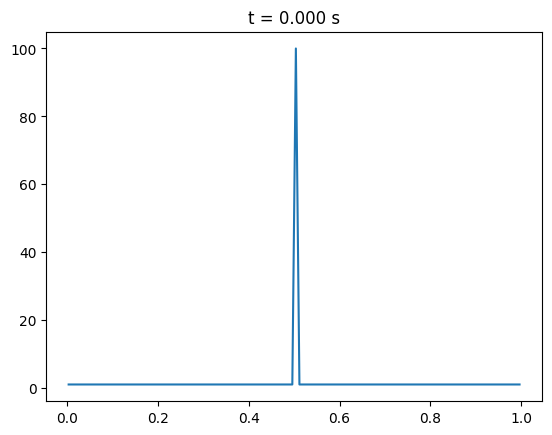

1.421415012263887e-146 s
1.421415012263887e-146 s


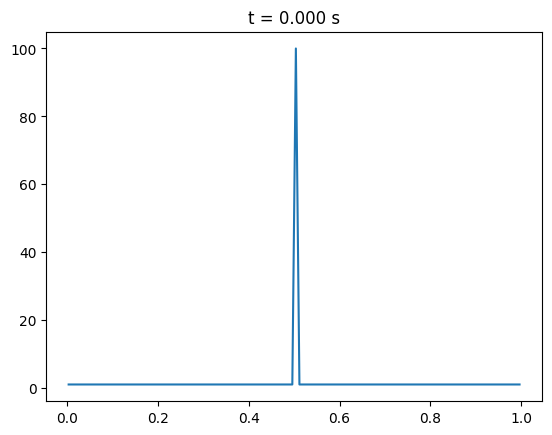

1.2563652425651925e-147 s
1.2563652425651925e-147 s


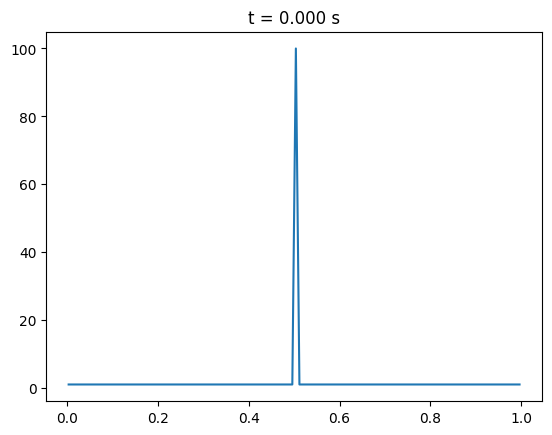

1.1104804783311617e-148 s
1.1104804783311617e-148 s


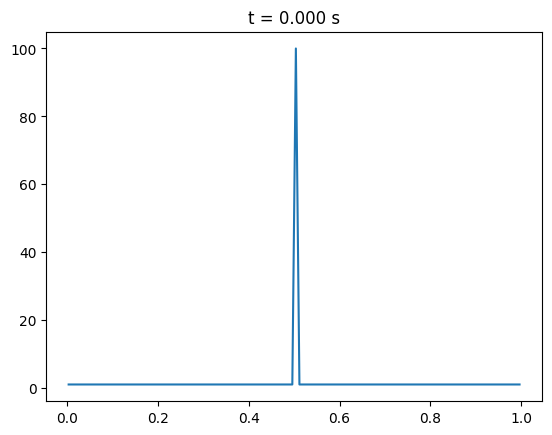

9.815353457540567e-150 s
9.815353457540567e-150 s


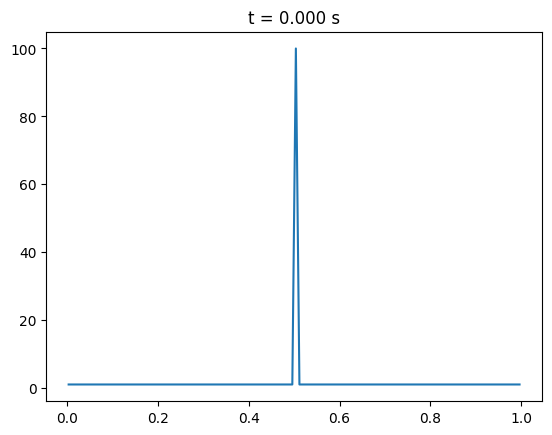

8.675628736962201e-151 s
8.675628736962201e-151 s


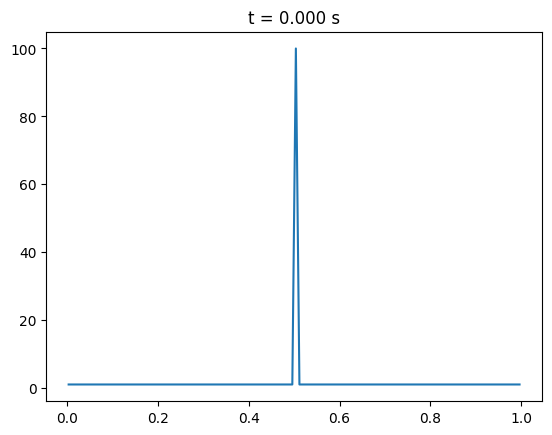

7.668244888703568e-152 s
7.668244888703568e-152 s


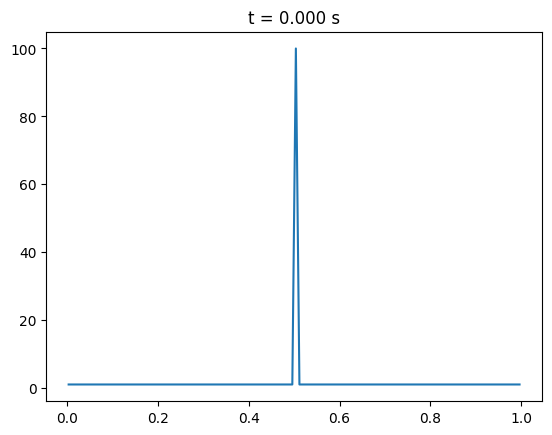

6.77783495075172e-153 s
6.77783495075172e-153 s


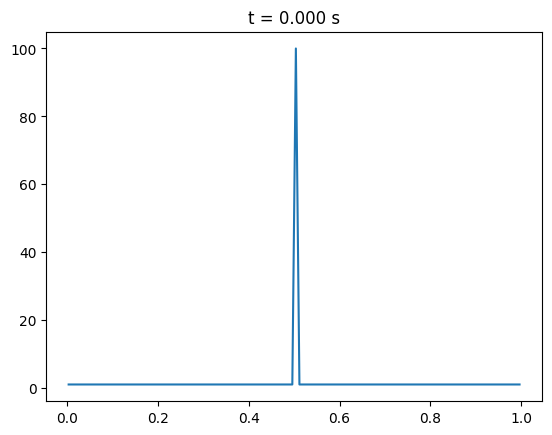

5.990816319299662e-154 s
5.990816319299662e-154 s


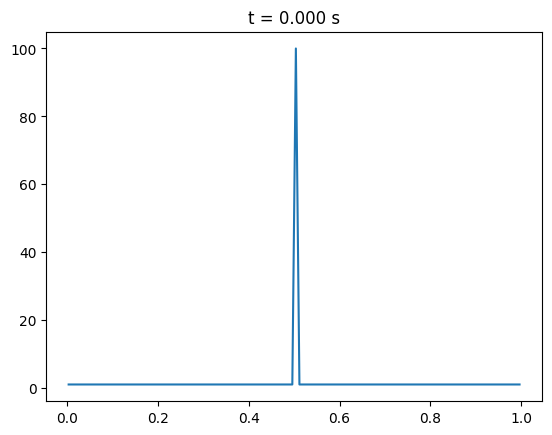

5.295183555274781e-155 s
5.295183555274781e-155 s


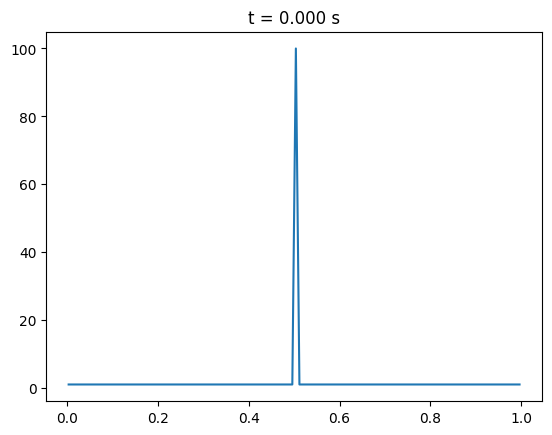

0.0 s
0.0 s


/tmp/ipykernel_152525/188751540.py:17: RuntimeWarning: invalid value encountered in divide
  v = W[1] / rho
/tmp/ipykernel_152525/2931535160.py:89: RuntimeWarning: invalid value encountered in multiply
  W_next = W[i] - (dt/dx).value*(F_l + F_r)


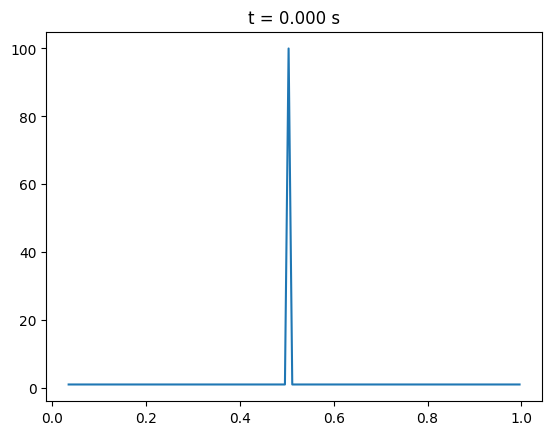

nan s
nan s


<Figure size 640x480 with 0 Axes>

In [10]:
t = t_start
while t < t_end:
    
    # initial state
    if(t == 0*u.s):
        T = T0
        rho = rho0
        v = v0
        P = pressure(ndens=rho0/mean_weight, T=T0)
        E = energy_density(rho0, v0, P, gamma)
    else:
        rho = rho_next * u.g/u.cm**3
        v = v_next * u.cm/u.s
        E = E_next * u.erg/u.cm**3
        T = temperature(ndens=rho/mean_weight, E=E, gamma=gamma)
        
    plt.title('t = %.3f %s' %(t.value, t.unit))
    plt.plot(x_mid, T)
    plt.show(), plt.clf()
    
    rho_next = np.zeros(N)
    v_next = np.zeros(N)
    E_next = np.zeros(N)

    # adapt timestep
    CFL = 0.5
    a = np.sqrt(gamma * P / rho)
    dt = (CFL * dx / np.max(np.linalg.norm(v) + a)).cgs
    
    print(dt)
    if t + dt > t_end:
        dt = t_end - t
    t += dt
    print(dt)
    for i in range(N):
        # Step 1: Define state vector
        W = np.array([rho, rho*np.linalg.norm(v), E]).T
        
        # Step 2: Compute flux vector
        F = flux(W)
        
        # Step 3: Compute the numerical flux
        # for i-1/2
        if(i == 0):            
            WL_l = W[-1]
            WR_l = W[i]
            FL_l = F[-1]
            FR_l = F[i]
        else:
            WL_l = W[i-1]
            WR_l = W[i]
            FL_l = F[i-1]
            FR_l = F[i]

            # for i+1/2
        if(i == N-1):            
            WL_r = W[i]
            WR_r = W[0]
            FL_r = F[i]
            FR_r = F[0]
        else:
            WL_r = W[i]
            WR_r = W[i+1]
            FL_r = F[i]
            FR_r = F[i+1]
            
        """
        # Step 4: Roe-averaged quantities at interface (density, velocity, enthalpy, and sound speed)
        # for i-1/2
        avrg_rho_l = np.sqrt(WL_l[0]*WR_l[0])
        avrg_v_l = (np.sqrt(WL_l[0])*WL_l[1]+np.sqrt(WR_l[0])*WR_l[1])/(np.sqrt(WL_l[0])+np.sqrt(WR_l[0]))
        HL_l = WL_l[2]*gamma/(gamma-1)/WL_l[0] + 0.5*np.linalg.norm(WL_l[1])**2
        HR_l = WR_l[2]*gamma/(gamma-1)/WR_l[0] + 0.5*np.linalg.norm(WR_l[1])**2
        avrg_H_l = (np.sqrt(WL_l[0])*HL_l+np.sqrt(WR_l[0])*HR_l)/(np.sqrt(WL_l[0])+np.sqrt(WR_l[0]))
        avrg_a_l = np.sqrt((gamma-1.)*(avrg_H_l - 0.5*avrg_v_l**2))
        
        # for i-1/2
        avrg_rho_r = np.sqrt(WL_r[0]*WR_r[0])
        avrg_v_r = (np.sqrt(WL_r[0])*WL_r[1]+np.sqrt(WR_r[0])*WR_r[1])/(np.sqrt(WL_r[0])+np.sqrt(WR_r[0]))
        HL_r = WL_r[2]*gamma/(gamma-1)/WL_r[0] + 0.5*np.linalg.norm(WL_r[1])**2
        HR_r = WR_r[2]*gamma/(gamma-1)/WR_r[0] + 0.5*np.linalg.norm(WR_r[1])**2
        avrg_H_r = (np.sqrt(WL_r[0])*HL_r+np.sqrt(WR_r[0])*HR_r)/(np.sqrt(WL_r[0])+np.sqrt(WR_r[0]))
        avrg_a_r = np.sqrt((gamma-1.)*(avrg_H_r - 0.5*avrg_v_r**2))
        """
        
        F_r = 0.5*(FL_r + FR_r)
        F_l = 0.5*(FL_l + FR_l)
    
        W_next = W[i] - (dt/dx).value*(F_l + F_r)
        #print(W[i,0], (dt/dx).value, (F_l[0] + F_r[0]),  W_next[0])
        #print(i, W_next)
        #rho_next[i] = W_next[0]
        rho_next[i], v_next[i], E_next[i] = W_next[0], W_next[1]/W_next[0], W_next[2]
    

In [66]:
E_next

0.0

In [5]:
# loop time
for n in range(0, Nt):
    dt = time[n+1]-time[n]
    
    W_now = np.zeros((N, ))
    W_next = np.zeros((N, 3))
    if(n == 0):
        T = T0
        ndens = ndens0
        P = pressure(ndens=ndens0, T=T0)
        E = energy_density(rho=rho0, v=v0, P=P, gamma=5./3)
    else:
        T = np.zeros_like(T0)
        
    # loop position 1D
    for i, x_half in enumerate(X):
        
        W = [rho, rho*v, E]
        F = [rho*v, rho*np.linalg.norm(v)**2 + P, (E+P)*np.linalg.norm(v)]
        S = [0., 0., 0.,]
        
        # finite volume method combined with Euler method
        W_next[i] = 
        
        if(i == 0):
            #P_left = pressure(ndens=ndens[N-1], T=T[N-1])
            P_left = pressure(ndens=ndens[N-1], T=T[0])
            P_right = pressure(ndens=ndens[i+1], T=T[i+1])

            F_left = ((E[N-1] + P_left)*np.linalg.norm(v[N-1])).cgs
            F_right = ((E[i+1] + P_right)*np.linalg.norm(v[i+1])).cgs

        elif(i == N-1):
            P_left = pressure(ndens=ndens[i-1], T=T[i-1])
            #P_right = pressure(ndens=ndens[0], T=T[0])
            P_right = pressure(ndens=ndens[0], T=T[N-1])

            F_left = ((E[i-1] + P_left)*np.linalg.norm(v[i-1])).cgs
            F_right = ((E[0] + P_right)*np.linalg.norm(v[0])).cgs
        else:
            P_left = pressure(ndens=ndens[i-1], T=T[i-1])
            #P_right = pressure(ndens=ndens[0], T=T[0])
            P_right = pressure(ndens=ndens[i+1], T=T[i+1])

            F_left = ((E[i-1] + P_left)*np.linalg.norm(v[i-1])).cgs
            F_right = ((E[i+1] + P_right)*np.linalg.norm(v[i+1])).cgs
            
        E_after = E[i] + dt/dx *(F_left-F_right)
        
        T[i] = temperature(ndens=ndens[i], E=E_after, gamma=5./3)

        #T[i] = E_after.cgs
        #print(T[i])
            
    plt.title('t = %.3f %s' %(n*dt.value, dt.unit))
    plt.plot(x_mid, T)
    plt.ylim(0, 101)
    plt.show(), plt.clf()

NameError: name 'v' is not defined

In [ ]:
boxsize = 1. * u.m
dx = boxsize/N
vol = dx**3
area = dx**2

# mesh grid
x_mid = np.linspace(0.5*dx, boxsize-0.5*dx, N)
X = x_mid



# Initial Conditions
mean_weight = 1.67e-24 * u.g
rho0 = np.ones(N) * mean_weight /u.m**3
ndens0 = rho0/mean_weight
T0 = np.zeros(N) * u.K
T0[N//2] = 1e2 * u.K
#T0[1] = 1e2 * u.K

np.random.seed(2025)
v0 = np.random.normal(loc=0, scale=0.1, size=N) * u.m/u.s
#rho0 = np.ones(N) * cosmo.critical_density0
#ndens0 = rho0/cst.m_p/molecular_weight

In [153]:
from roe import roesol

# Simulation parameters
N = 2000 # resolution
boxsize = 1. * u.m
dx = boxsize/(N+2)
vol = dx**3
dr = (x_mid[1]-x_mid[0]).cgs.value
volume = np.ones(N+2)*vol.cgs.value

# Time
t_start = 0 * u.s
t_end = 3*60 * u.s
Nt = 1000
time = np.linspace(t_start, t_end, Nt+1)
dt = (time[1]-time[0]).cgs.value

# Initial Conditions
gamma = 5./3     # adiabatic index for ideal gas
mean_weight = 1.67e-24 * u.g
rho0 = np.ones(N+2) * mean_weight /u.m**3
ndens0 = rho0/mean_weight
T0 = np.zeros(N+2) * u.K
T0[N//2] = 1e2 * u.K
v0 = np.random.normal(loc=0, scale=0.1, size=N+2) * u.m/u.s
P0 = pressure(ndens=ndens0, T=T0).to('g/(cm*s^2)')
E0 = energy_density(rho=rho0, v=v0, P=P0, gamma=5./3).to('erg/cm^3')

state = np.array([rho0.cgs.value, (v0*rho0).cgs.value, E0.to('erg/cm^3').value], dtype=np.float64, order='F').T
flux = np.array([(v0[1:]*rho0[1:]).cgs.value, (rho0[1:]*v0[1:]**2+P0[1:]).to('g/(cm*s^2)').value, ((E0[1:]+P0[1:])*v0[1:]).cgs.value], dtype=np.float64, order='F').T
ictl = 0

print(state)
roesol(dr, dt, gamma, volume, state, flux, N, ictl)

[[ 1.67000000e-30 -2.90883704e-29  0.00000000e+00]
 [ 1.67000000e-30  6.66067970e-30  0.00000000e+00]
 [ 1.67000000e-30  1.84153006e-30  0.00000000e+00]
 ...
 [ 1.67000000e-30 -1.08528998e-31  0.00000000e+00]
 [ 1.67000000e-30 -1.06931048e-29  0.00000000e+00]
 [ 1.67000000e-30 -8.68214530e-30  0.00000000e+00]]


In [154]:
state

array([[ 1.67000000e-30, -2.90883704e-29,  0.00000000e+00],
       [ 1.67000000e-30,  6.66067970e-30,  0.00000000e+00],
       [ 1.67000000e-30,  1.84153006e-30,  0.00000000e+00],
       ...,
       [ 1.67000000e-30, -1.08528998e-31,  0.00000000e+00],
       [ 1.67000000e-30, -1.06931048e-29,  0.00000000e+00],
       [ 1.67000000e-30, -8.68214530e-30,  0.00000000e+00]])

In [98]:
(E0+P0)*v0.cgs

<Quantity [-0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
           -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
            0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
            0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
           -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
           -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
           -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
           -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
           -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
            0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
           -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
           -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
           -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
            0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
            0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        

<Quantity [-1.54291596e-30,  1.22625690e-29, -2.40293298e-29,
           -1.10791478e-29, -1.68215907e-30,  3.58546758e-29,
            2.32749250e-29, -3.46309791e-30,  1.27519077e-29,
            3.42439596e-30, -1.73929861e-29, -1.38288707e-29,
           -1.75983879e-29, -1.48226970e-30,  2.64182902e-30,
           -2.98816949e-29,  1.77601457e-29,  6.19904085e-31,
           -2.73475744e-30, -5.48106640e-30,  2.65359076e-29,
           -3.15267637e-30, -3.03477361e-30,  1.19889335e-29,
           -1.18110891e-32,  1.30621883e-29,  1.45275172e-30,
            1.10646801e-30,  2.00494345e-29, -1.02981070e-30,
           -1.50451360e-29, -2.10294423e-29,  9.45768843e-31,
           -1.61358509e-29,  1.25008777e-29,  4.64571269e-30,
           -5.18962772e-30, -1.09202133e-29, -1.21823132e-30,
            9.88535682e-30,  1.43219864e-29, -1.99427794e-29,
            3.17557302e-29, -1.07745736e-29, -1.97426846e-29,
            2.59218248e-29,  2.03125696e-29,  1.56368309e-29,
        

In [92]:
P0

<Quantity [0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
           0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e

(128, 3)

In [2]:
def primitive_to_conserved(rho, v, P, gamma, vol):
    """ Calculate conserved quantity (mass, momentum and energy) the primitive """
    mass   = rho * vol
    moment   = rho * v * vol
    energy = (P/(gamma-1) + 0.5*rho*np.linalg.norm(v)**2)*vol

    return mass, moment, energy

def conserved_to_primitive(mass, moment, energy, gamma, vol):
    """ Calculate the primitive variables from the conserved quantity """
    rho = mass / vol
    v = moment / rho / vol
    P = (energy/vol - 0.5*rho*np.linalg.norm(v)**2) * (gamma-1)

    return rho, v, P


def W_vect(rho, vel, energy, vol):
    return vol*np.array([rho, rho*vel, energy])

def F_vect(rho, vel, energy, gamma, vol):
    P = (energy/vol - 0.5*rho*np.linalg.norm(v)**2) * (gamma-1)
    return vol*np.array([rho, rho*np.linalg.norm(v)**2+P, np.linalg.norm(v)*(rho*energy + P)])

In [3]:
# Simulation parameters
N = 128 # resolution
boxsize = 1. * u.kpc
dx = boxsize/N
vol = dx**3
area = dx**2
gamma = 5./3     # adiabatic index for ideal gas
molecular_weight = 1.33

# mesh grid
x_mid = np.linspace(0.5*dx, boxsize-0.5*dx, N)
#X, Y = np.array(np.meshgrid(x_mid, x_mid))
X = x_mid

# Time
t_start = 0 * u.s
t_end = 1e5 * u.s
Nt = 100
time = np.linspace(t_start, t_end, Nt)

# Initial Conditions
T0 = np.zeros(N) * u.K
T0[0] = 5e2 * u.K
T0[1] = 5e2 * u.K
#T0[N//2] = 5e2 * u.K
#T0[N//2+1] = 5e2 * u.K

rho0 = np.ones(N) * 1e-9 * u.g/u.cm**3
v0 = np.ones(N)* 0.1 * u.m/u.s
p0 = (rho0 * cst.k_B * T0/molecular_weight/cst.m_p).to('g/(m*s**2)')
#E0 = (p0*vol/(gamma - 1.) + 0.5*rho0*np.linalg.norm(v0)**2*vol).to('J')
E0 = (p0/(gamma - 1.) + 0.5*rho0*np.linalg.norm(v0)**2).cgs

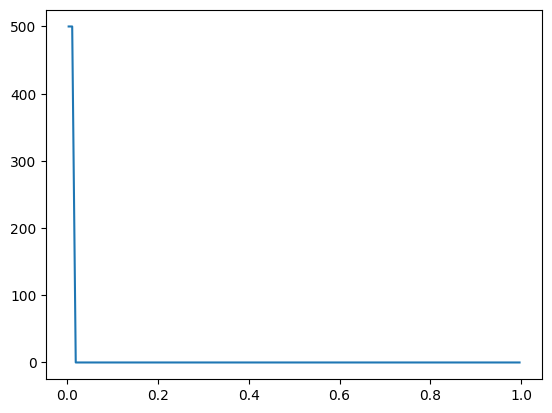

In [4]:
plt.plot(x_mid, T0)

In [31]:
# loop time
for n, t in enumerate(time):
    dt = time[n+1]-time[n]
            
    if(n == 0):
        rho = rho0
        v = v0
        E = E0
        P = 
    a = np.sqrt(gamma * P / rho)
    dt = CFL * dx / np.max(np.abs(u) + a)
        
    # loop position 1D
    for i, x_half in enumerate(X):
        
        
        W_now = [rho[i], (rho[i]*np.linalg.norm(v[i])).cgs, E[i]]
        
        P_left = (E[i-1] - 0.5*rho[i-1]*np.linalg.norm(v[i-1])**2) * (gamma-1)
        P_right = (E[i+1] - 0.5*rho[i+1]*np.linalg.norm(v[i+1])**2) * (gamma-1)
        
        F_left = [(rho[i-1]*np.linalg.norm(v[i-1])).cgs, 
                  (rho[i-1]*np.linalg.norm(v[i-1])**2 + P_left).cgs, 
                  ((E[i-1] + P_left)*np.linalg.norm(v[i-1])).cgs]

        F_right = [(rho[i+1]*np.linalg.norm(v[i+1])).cgs, 
                  (rho[i+1]*np.linalg.norm(v[i+1])**2 + P_right).cgs, 
                  ((E[i+1] + P_right)*np.linalg.norm(v[i+1])).cgs]

        W_after = W_now + dt/dx *(np.array(F_left)-np.array(F_right))
        print(W_after)
        #W_after = np.zeros_like(W_now)
        
    #plt.title('t = %.3f' %(time[n]))
    #plt.plot(x_mid, T_after)
    #plt.show(), plt.clf()

TypeError: only dimensionless scalar quantities can be converted to Python scalars

In [67]:
(cst.k_B * dt * area / dx).cgs #.to('W/K')

<Quantity 333164.23198264 cm4 P / K>

In [57]:
cst.k_B.cgs

<Quantity 1.380649e-16 erg / K>

In [66]:
u.dyn??

[1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1]
[ 1.          1.          1.          1.          1.          1.
  1.          1.          1.          1.          1.          1.
  1.          1.          1.          1.          1.          

/tmp/ipykernel_8701/2127298948.py:106: RuntimeWarning: invalid value encountered in sqrt
  a = np.sqrt(gamma * P / rho)


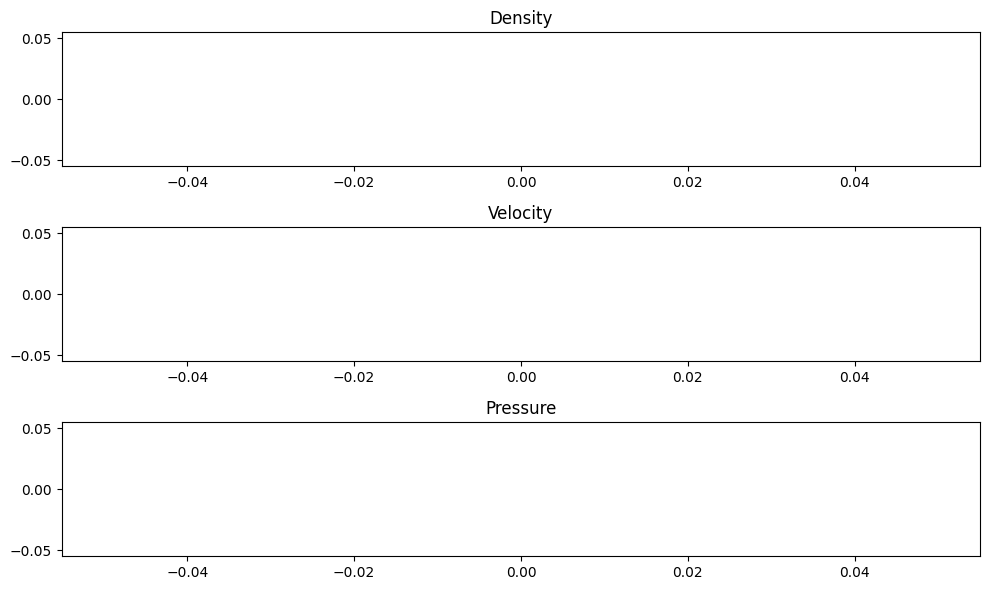

In [111]:
# Parameters
gamma = 1.4
nx = 200           # number of cells
xmax = 1.0
CFL = 0.5
t_end = 0.2

dx = xmax / nx
x = np.linspace(dx/2, xmax - dx/2, nx)

# Initial Conditions (Sod shock tube)
def initial_conditions():
    rho = np.ones(nx)
    v = np.zeros(nx)
    P = np.ones(nx) * 0.1

    rho[:nx//2] = 1.0
    P[:nx//2] = 1.0

    E = P / (gamma - 1) + 0.5 * rho * v**2
    return rho, rho * v, E

# Convert to primitive variables
def primitive(W):
    rho = W[0]
    u = W[1] / rho
    E = W[2]
    P = (gamma - 1) * (E - 0.5 * rho * u**2)
    return rho, u, P

# Compute fluxes
def flux(W):
    rho, u, P = primitive(W)
    F = np.zeros_like(W)
    F[0] = rho * u
    F[1] = rho * u**2 + P
    F[2] = (W[2] + P) * u
    return F

# Roe-averaged variables
def roe_averages(WL, WR):
    rL, uL, PL = primitive(WL)
    rR, uR, PR = primitive(WR)
    HL = (WL[2] + PL) / rL
    HR = (WR[2] + PR) / rR

    sqrt_rL = np.sqrt(rL)
    sqrt_rR = np.sqrt(rR)
    denom = sqrt_rL + sqrt_rR

    u_avg = (sqrt_rL * uL + sqrt_rR * uR) / denom
    H_avg = (sqrt_rL * HL + sqrt_rR * HR) / denom
    a_avg = np.sqrt((gamma - 1) * (H_avg - 0.5 * u_avg**2))

    return u_avg, a_avg, H_avg

# Roe flux function
def roe_flux(WL, WR):
    FL = flux(WL)
    FR = flux(WR)
    deltaW = WR - WL

    u, a, H = roe_averages(WL, WR)

    # Eigenvalues
    lam = np.array([u - a, u, u + a])
    # Entropy fix
    epsilon = 0.1 * a
    lam = np.where(np.abs(lam) < epsilon, 0.5 * (lam**2 / epsilon + epsilon), np.abs(lam))

    # Eigenvectors
    r1 = np.array([1, u - a, H - u * a])
    r2 = np.array([1, u, 0.5 * u**2])
    r3 = np.array([1, u + a, H + u * a])

    # Compute wave strengths (α)
    rhoL, uL, PL = primitive(WL)
    rhoR, uR, PR = primitive(WR)

    dU = deltaW
    du = uR - uL
    dP = PR - PL

    alpha2 = (gamma - 1) * (dU[2] - u * dU[1]) / a**2
    alpha1 = 0.5 * ((dU[0] - alpha2) - dU[1] / a)
    alpha3 = dU[0] - alpha1 - alpha2

    # Total flux
    flux_roe = 0.5 * (FL + FR) - 0.5 * (
        alpha1 * lam[0] * r1 +
        alpha2 * lam[1] * r2 +
        alpha3 * lam[2] * r3
    )
    return flux_roe

# Main solver
def solve():
    rho, rhov, E = initial_conditions()
    W = np.array([rho, rhov, E])

    t = 0.0
    while t < t_end:
        # Compute maximum wave speed
        rho, u, P = primitive(W)
        print(P )#/ rho)
        a = np.sqrt(gamma * P / rho)
        dt = CFL * dx / np.max(np.abs(u) + a)
        if t + dt > t_end:
            dt = t_end - t
        t += dt

        # Compute fluxes at interfaces
        F_num = np.zeros((3, nx + 1))
        for i in range(1, nx):
            F_num[:, i] = roe_flux(W[:, i - 1], W[:, i])

        # Update solution
        W[:, 1:-1] -= dt / dx * (F_num[:, 2:-1] - F_num[:, 1:-2])

        # Boundary conditions (zero-gradient)
        W[:, 0] = W[:, 1]
        W[:, -1] = W[:, -2]

    return x, W

# Run solver and plot
x, W = solve()
rho, u, P = primitive(W)

plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 1)
plt.plot(x, rho)
plt.title('Density')

plt.subplot(3, 1, 2)
plt.plot(x, u)
plt.title('Velocity')

plt.subplot(3, 1, 3)
plt.plot(x, P)
plt.title('Pressure')
plt.tight_layout()
plt.show()
